# Chặng5 — Suy luận, TTA, resolution, temperature và AMP
Gắn **dataset ảnh + output notebook chặng4** làm input. Bật GPU và Internet.
Save Version → Save & Run All. Không cần ZIP code, không train lại, không đánh giá test.

Cần best.pt của T00 và T05 từ output chặng4. stage4_results.zip không chứa trọng số.
16 cấu hình:8 phương pháp ×2 checkpoint. Đo thực tế batch1/32,10 warmup +100 lượt.
Calibration fit trên fullval và báo rõ metrics cũng đo trên tập fit; không phải holdout độc lập.


In [1]:
from pathlib import Path
import sys, subprocess, shutil, json, os, zipfile
import torch

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

IMAGES_DIR = Path(
    "/kaggle/input/datasets/luuquangkhai/data-labd2/images"
)
STAGE4_INPUT = None  # Có thể điền đường dẫn thư mục checkpointstage4
PREVIOUS_OUTPUT = None

WORK = Path("/kaggle/working/deepweeds_stage5")
OUT = WORK / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

EXPS = ("T00", "T05_smoothing")


def find_checkpoint(seed_dir):
    """Nhận file best.pt hoặc thư mục checkpoint đã giải nén."""
    seed_dir = Path(seed_dir)
    pt = seed_dir / "best.pt"

    if pt.is_file():
        return "file", pt

    matches = [
        p.parent
        for p in seed_dir.glob("**/data.pkl")
        if (p.parent / "data").is_dir()
        and (p.parent / "version").is_file()
    ]
    if len(matches) == 1:
        return "directory", matches[0]

    raise RuntimeError(
        f"Không tìm được một checkpoint duy nhất trong {seed_dir}. "
        f"Thư mục data.pkl tìm thấy: {matches}"
    )


# Tìm thư mục chứa runs/T00 và runs/T05_smoothing.
if STAGE4_INPUT is None:
    candidates = []

    for seed_dir in Path("/kaggle/input").glob(
        "**/runs/T05_smoothing/seed0"
    ):
        source = seed_dir.parents[2]
        try:
            for exp in EXPS:
                find_checkpoint(source / "runs" / exp / "seed0")
            candidates.append(source)
        except RuntimeError:
            continue

    candidates = sorted(set(candidates))
    if len(candidates) != 1:
        raise RuntimeError(
            "Hãy điền STAGE4_INPUT bằng đường dẫn checkpointstage4 "
            f"trên Kaggle. Các nguồn tìm thấy: {candidates}"
        )
    STAGE4_INPUT = candidates[0]

STAGE4_INPUT = Path(STAGE4_INPUT)
print("Nguồn checkpoint:", STAGE4_INPUT)

# Tạo cấu trúc chuẩn mà các cell chặng 5 đang sử dụng.
STAGE4_OUTPUT = WORK / "stage4_input"
STAGE4_OUTPUT.mkdir(parents=True, exist_ok=True)
configs = []

for exp in EXPS:
    kind, source = find_checkpoint(
        STAGE4_INPUT / "runs" / exp / "seed0"
    )
    destination = STAGE4_OUTPUT / "runs" / exp / "seed0" / "best.pt"
    destination.parent.mkdir(parents=True, exist_ok=True)

    temporary = destination.with_suffix(".tmp")

    if kind == "file":
        shutil.copyfile(source, temporary)
    else:
        # Khôi phục container ZIP của PyTorch từ các file đã giải nén.
        # Giữ nguyên data.pkl và các tensor, không huấn luyện lại.
        print(f"{exp}: đóng lại checkpoint từ {source}")
        with zipfile.ZipFile(
            temporary, "w", compression=zipfile.ZIP_STORED
        ) as archive:
            for item in sorted(source.rglob("*")):
                if item.is_file():
                    archive.write(
                        item,
                        "checkpoint/" + item.relative_to(source).as_posix(),
                    )

    temporary.replace(destination)

    # Chỉ đọc checkpoint do bạn tạo từ chặng 4.
    saved = torch.load(
        destination, map_location="cpu", weights_only=False
    )
    required = {"model", "signature", "mean", "std"}
    if not required.issubset(saved):
        raise RuntimeError(
            f"{exp}: checkpoint thiếu {required - set(saved)}"
        )

    config = dict(saved["signature"]["config"])
    if config.get("exp_id") != exp:
        raise RuntimeError(f"Checkpoint không đúng thí nghiệm {exp}")

    configs.append(config)
    del saved
    print(f"{exp}: checkpoint đọc thành công")

# Chặng 5 có thể lấy cấu hình trực tiếp từ signature đã lưu.
(STAGE4_OUTPUT / "single_axis_configs.json").write_text(
    json.dumps(configs, indent=2), encoding="utf-8"
)

if PREVIOUS_OUTPUT:
    previous = Path(PREVIOUS_OUTPUT)
    assert (previous / "suite_identity.json").is_file()
    assert (previous / "stage5_summary.json").is_file()
    assert not (OUT / "methods").exists(), (
        "Đặt PREVIOUS_OUTPUT=None khi đã copy trong session này"
    )
    shutil.copytree(previous, OUT, dirs_exist_ok=True)

assert (IMAGES_DIR / "20160928-140314-0.jpg").is_file(), (
    "Kiểm tra IMAGES_DIR"
)

code_path = str(WORK / "code")
if code_path not in sys.path:
    sys.path.insert(0, code_path)

print("Checkpoint source:", STAGE4_OUTPUT)
print("Output:", OUT)

Nguồn checkpoint: /kaggle/input/datasets/luuquangkhai/weightstage4/checkpointstage4
T00: đóng lại checkpoint từ /kaggle/input/datasets/luuquangkhai/weightstage4/checkpointstage4/runs/T00/seed0/best/best
T00: checkpoint đọc thành công
T05_smoothing: đóng lại checkpoint từ /kaggle/input/datasets/luuquangkhai/weightstage4/checkpointstage4/runs/T05_smoothing/seed0/best/best
T05_smoothing: checkpoint đọc thành công
Checkpoint source: /kaggle/working/deepweeds_stage5/stage4_input
Output: /kaggle/working/deepweeds_stage5/outputs


## Code và dữ liệu nhãn nhúng
Chạy các cell tiếp theo để tạo module và CSV nguyên byte trong working. Không cần dataset code.


In [2]:
import hashlib, base64, zlib
def write_embedded(relative, payload, expected):
    assert hashlib.sha256(payload).hexdigest() == expected, f'Embedded file changed: {relative}'
    target = WORK / relative
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_bytes(payload)


In [3]:
# code/benchmark.py
_embedded_source = r'''"""Forward-only latency. Inputs already reside on device; preprocessing excluded."""
import copy
import time
import numpy as np
import torch


def bench(fn, warmup=10, iters=100, sync=None):
    if warmup < 10 or iters < 50:
        raise ValueError("Use at least 10 warmup and 50 measured iterations")
    synchronize = sync or (lambda: None)
    for _ in range(warmup):
        fn()
    samples = []
    for _ in range(iters):
        synchronize()
        start = time.perf_counter()
        fn()
        synchronize()
        samples.append((time.perf_counter() - start) * 1000)
    return {"p50": float(np.percentile(samples, 50)), "p95": float(np.percentile(samples, 95)),
            "p99": float(np.percentile(samples, 99)), "mean": float(np.mean(samples)),
            "n": iters, "samples_ms": samples}


def latency_report(model, batch_size, img_size, dtype="fp32", device="cuda", warmup=10, iters=100):
    device = torch.device(device)
    if dtype not in ("fp32", "amp", "fp16"):
        raise ValueError("dtype must be fp32/amp/fp16")
    if dtype != "fp32" and device.type != "cuda":
        raise ValueError("AMP/FP16 benchmarks require CUDA")
    # Do not mutate training model's device, dtype or BN/dropout mode.
    measured = copy.deepcopy(model).to(device).eval()
    measured = measured.half() if dtype == "fp16" else measured.float()
    x = torch.randn(batch_size, 3, img_size, img_size, device=device,
                    dtype=torch.float16 if dtype == "fp16" else torch.float32)
    sync = (lambda: torch.cuda.synchronize(device)) if device.type == "cuda" else None
    with torch.inference_mode(), torch.autocast(device.type, enabled=dtype == "amp"):
        result = bench(lambda: measured(x), warmup, iters, sync)
    return {**result, "gpu": torch.cuda.get_device_name(device) if device.type == "cuda" else "CPU",
            "dtype": dtype, "batch": batch_size, "img_size": img_size, "warmup": warmup,
            "images_per_s": batch_size / (result["p50"] / 1000), "torch": torch.__version__,
            "preprocessing_included": False, "host_to_device_included": False, "bn_fused": False}


def tta_latency(model, k_views, **kw):
    """Measure actual supplied view callables and aggregation, with preloaded input."""
    views = kw.pop("views", None)
    if views is None or len(views) != k_views:
        raise ValueError("Provide one callable per view; latency is never inferred by multiplying K")
    device = torch.device(kw.pop("device", "cuda:0"))
    batch = kw.pop("batch_size", 1)
    size = kw.pop("img_size", 224)
    warmup, iters = kw.pop("warmup", 10), kw.pop("iters", 100)
    if kw:
        raise ValueError(f"Unsupported options: {list(kw)}")
    measured = copy.deepcopy(model).to(device).eval()
    x = torch.randn(batch, 3, size, size, device=device)
    def forward():
        return torch.stack([measured(view(x)).float().softmax(-1) for view in views]).mean(0)
    sync = (lambda: torch.cuda.synchronize(device)) if device.type == "cuda" else None
    with torch.inference_mode():
        return bench(forward, warmup, iters, sync)
'''
_lines = _embedded_source.split('\n')
for _line_index in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]:
    _lines[_line_index] += '\r'
write_embedded('code/benchmark.py', '\n'.join(_lines).encode('utf-8'), 'f43f2d35794d930f56fafb0e4a58fa1e7b81a88f6220b69b3f1bebe110649b4e')


In [4]:
# code/dataset.py
_embedded_source = r'''"""Official splits and reproducible image loading; preserve original split labels."""
from pathlib import Path
import hashlib
import json
import random
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T

NUM_CLASSES = 9
CLASS_NAMES = ["Chinee apple", "Lantana", "Parkinsonia", "Parthenium",
               "Prickly acacia", "Rubber vine", "Siam weed", "Snake weed", "Negative"]
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def load_split(labels_dir, fold=0):
    return tuple(pd.read_csv(Path(labels_dir) / f"{s}_subset{fold}.csv")
                 for s in ("train", "val", "test"))

def check_split(train_df, val_df, test_df, images_dir, verify_files=True):
    frames = dict(zip(("train", "val", "test"), (train_df, val_df, test_df)))
    names = {}
    for split, df in frames.items():
        if not {"Filename", "Label"}.issubset(df.columns):
            raise ValueError(f"Missing split columns: {split}")
        if df[["Filename", "Label"]].isna().any().any() or df.Filename.duplicated().any():
            raise ValueError(f"Null/duplicate records: {split}")
        if set(df.Label) != set(range(NUM_CLASSES)):
            raise ValueError(f"Expected labels 0..8: {split}")
        if any(Path(n).name != n or "\\" in n for n in df.Filename):
            raise ValueError("Expected bare image filenames")
        names[split] = set(df.Filename)
    overlap = {f"{a}_{b}": len(names[a] & names[b])
               for a, b in (("train", "val"), ("train", "test"), ("val", "test"))}
    union = set.union(*names.values())
    if any(overlap.values()) or len(union) != 17509:
        raise ValueError(f"Invalid split coverage/overlap: {len(union)}, {overlap}")
    for split, df in frames.items():
        if abs(len(df) / 17509 - (0.6 if split == "train" else 0.2)) > 0.01:
            raise ValueError(f"Invalid split ratio: {split}")
    if verify_files:
        missing = [n for n in union if not (Path(images_dir) / n).is_file()]
        if missing:
            raise FileNotFoundError(f"{len(missing)} missing images: {missing[:5]}")
    result = {"n": {s: len(df) for s, df in frames.items()}, "overlap": overlap,
              "union": len(union), "verified_all_file_paths": verify_files,
              "per_class": {s: df.Label.value_counts().sort_index().to_dict() for s, df in frames.items()}}
    print("Split:", result["n"], "overlap:", overlap)
    return result

def csv_hashes(labels_dir, fold=0):
    files = ["labels.csv"] + [f"{s}_subset{fold}.csv" for s in ("train", "val", "test")]
    return {n: hashlib.sha256((Path(labels_dir) / n).read_bytes()).hexdigest() for n in files}

def verified_stage1(path, images_dir, labels_dir, fold):
    """Reuse exhaustive decode only for unchanged source path and CSV bytes."""
    if not path or fold != 0:
        return False
    summary = json.loads(Path(path).read_text(encoding="utf-8"))
    return (summary.get("status") == "PASS" and summary.get("union") == 17509
            and summary.get("labels_sha256") == csv_hashes(labels_dir, fold)
            and Path(summary.get("images_source", "")).as_posix() == Path(images_dir).as_posix())

def build_transforms(train, img_size=224, aug="basic", mean=IMAGENET_MEAN, std=IMAGENET_STD):
    if aug not in ("basic", "color", "trivial", "randaug"):
        raise ValueError(f"Unknown augmentation: {aug}")
    if train:
        steps = [T.RandomResizedCrop(img_size, interpolation=T.InterpolationMode.BICUBIC),
                 T.RandomHorizontalFlip()]
        if aug == "color":
            steps += [T.ColorJitter(0.2, 0.2, 0.2, 0.05)]
        elif aug == "trivial":
            steps += [T.TrivialAugmentWide()]
        elif aug == "randaug":
            steps += [T.RandAugment()]
    else:
        steps = [T.Resize(round(img_size * 256 / 224), interpolation=T.InterpolationMode.BICUBIC),
                 T.CenterCrop(img_size)]
    return T.Compose(steps + [T.ToTensor(), T.Normalize(mean, std)])

class DeepWeedsDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.images_dir, self.transform = Path(images_dir), transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        with Image.open(self.images_dir / row.Filename) as source:
            image = source.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row.Label), row.Filename

def seed_worker(worker_id):
    seed = torch.initial_seed() % 2**32
    np.random.seed(seed)
    random.seed(seed)

def make_loader(df, images_dir, transform, batch_size, train, sampler=None, num_workers=2, seed=0):
    if sampler not in (None, "balanced") or (sampler and not train):
        raise ValueError("Sampler only supports None or balanced on train")
    generator = torch.Generator().manual_seed(seed)
    weighted = None
    if sampler == "balanced":
        counts = df.Label.value_counts()
        weights = torch.tensor([1 / counts[y] for y in df.Label], dtype=torch.double)
        weighted = WeightedRandomSampler(weights, len(df), replacement=True, generator=generator)
    return DataLoader(DeepWeedsDataset(df, images_dir, transform), batch_size=batch_size,
                      shuffle=train and weighted is None, sampler=weighted,
                      drop_last=train and len(df) % batch_size == 1 and len(df) > batch_size,
                      num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                      worker_init_fn=seed_worker, generator=generator, persistent_workers=False)

'''
_lines = _embedded_source.split('\n')
for _line_index in [116]:
    _lines[_line_index] += '\r'
write_embedded('code/dataset.py', '\n'.join(_lines).encode('utf-8'), 'ed9a77345ac3c10fb0976e769edb4b639773a02889fb4911008a6e8e274ae812')


In [5]:
# code/eval.py
_embedded_source = r'''#!/usr/bin/env python3
"""eval.py - công cụ đánh giá chính thức của Lab Day 2 (DeepWeeds).

File này đã hoàn chỉnh: sinh viên KHÔNG sửa công thức chỉ số. Mọi con số trong
results.xlsx và báo cáo phải khớp với kết quả của file này (RUBRIC.md, mục I).
Chỉ phụ thuộc numpy và pandas.

Định nghĩa chỉ số (README.md, mục 2.2)
--------------------------------------
- top-1 accuracy : số ảnh đoán đúng / tổng số ảnh, không trọng số theo lớp.
- macro-F1       : trung bình cộng F1 của 9 lớp (lớp không có dự đoán đúng có F1 = 0).
- balanced acc.  : trung bình recall của các lớp có ảnh trong tập.
- precision / recall / F1 theo lớp, ma trận nhầm lẫn (hàng = nhãn thật).
- ECE            : 15 bin đều theo độ tin cậy (= max softmax); bin m là (b_{m-1}, b_m].
                   ECE = sum_m (n_m / n) * |acc_m - conf_m|
- mean +- std    : qua các seed, std mẫu (ddof = 1).

Định dạng file dự đoán (mỗi seed một file)
------------------------------------------
    Filename, y_true, y_pred, p0, p1, ..., p8
p0..p8 là xác suất softmax, thứ tự theo cột `Label` của labels.csv
(0 = Chinee Apple ... 7 = Snake Weed, 8 = Negatives). Tên file chứa `seed<k>`,
ví dụ predictions/F01_seed0_test.csv. Hàm `save_predictions(...)` trong file này ghi
đúng định dạng đó (`from eval import save_predictions`).

Cách dùng
---------
    # 1) Tính chỉ số cho một nhóm file (một cấu hình, nhiều seed)
    python eval.py score --pred "predictions/F01_seed*_test.csv" \
        --test-csv labels/test_subset0.csv --labels labels/labels.csv --tag F01

    # 2) Tự chấm phần I của RUBRIC (chung kết so với mốc)
    python eval.py grade \
        --final    "predictions/F01_seed*_test.csv" \
        --baseline "predictions/T00_seed*_test.csv" \
        --uncal    "predictions/F01_uncal_seed*_test.csv" \
        --final-val "predictions/F01_seed*_val.csv" \
        --latency-p95-ms 41.5 --latency-method proper \
        --test-csv labels/test_subset0.csv --labels labels/labels.csv

`--uncal` (cùng cấu hình nhưng chưa temperature scaling) và `--final-val` (dự đoán
trên val) là tùy chọn; thiếu thì các ý I4(a) hoặc I4(b) ghi là "chưa chấm được".
"""
from __future__ import annotations

import argparse
import glob
import json
import math
import re
import sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

# --------------------------------------------------------------------------- #
# Hằng số
# --------------------------------------------------------------------------- #
NUM_CLASSES = 9
ECE_BINS = 15
PROB_SUM_TOL = 1e-3  # xác suất mỗi dòng phải cộng bằng 1 (sai số cho phép)

# Thứ tự lớp theo cột `Label` của labels.csv (lấy từ deepweeds.py của tác giả).
CLASS_NAMES = [
    "Chinee Apple", "Lantana", "Parkinsonia", "Parthenium", "Prickly Acacia",
    "Rubber Vine", "Siam Weed", "Snake Weed", "Negatives",
]

# Hai lớp khó nhất và mốc recall (%) từ bài báo gốc (README.md, mục 2.3).
HARD_CLASSES = {"Chinee Apple": 88.5, "Snake Weed": 88.8}

# ---- Ngưỡng chấm RUBRIC mục I (TẠM THỜI: giảng viên có thể chỉnh tại đây) ---- #
ACC_TIERS = [(95.7, 7), (95.1, 6), (94.0, 5), (92.0, 3), (90.0, 1)]  # I1: (acc %, điểm)
I2_MIN_DELTA = 0.01          # I2: Delta macro-F1 tối thiểu để đạt 5 điểm
HARD_FLOORS = [(85.0, 3), (80.0, 2)]  # I3: sàn recall (%) cho cả hai lớp khó
I3_MIN_POINTS = 1            # I3: có báo cáo đầy đủ nhưng dưới 80%
I4_MAX_VAL_TEST_GAP = 0.02   # I4(b): |macro-F1 val - macro-F1 test| tối đa
I5_P95_BUDGET_MS = 100.0     # I5: ngân sách p95 ở batch 1
MIN_SEEDS = 3


# --------------------------------------------------------------------------- #
# Đọc và kiểm tra file dự đoán
# --------------------------------------------------------------------------- #
@dataclass
class Pred:
    path: str
    seed: int | None
    filenames: np.ndarray
    y_true: np.ndarray
    y_pred: np.ndarray
    probs: np.ndarray


def parse_seed(path: str) -> int | None:
    m = re.search(r"seed[_-]?(\d+)", Path(path).name)
    return int(m.group(1)) if m else None


def read_pred(path: str, num_classes: int = NUM_CLASSES) -> Pred:
    """Đọc một file dự đoán và kiểm tra định dạng. Ném ValueError nếu sai."""
    df = pd.read_csv(path)
    prob_cols = [f"p{i}" for i in range(num_classes)]
    missing = [c for c in ["Filename", "y_true", "y_pred", *prob_cols] if c not in df.columns]
    if missing:
        raise ValueError(f"{path}: thiếu cột {missing}")
    extra_p = [c for c in df.columns if re.fullmatch(r"p\d+", c) and c not in prob_cols]
    if extra_p:
        raise ValueError(f"{path}: có cột xác suất ngoài p0..p{num_classes - 1}: {extra_p}")
    if len(df) == 0:
        raise ValueError(f"{path}: file rỗng")
    if df["Filename"].duplicated().any():
        raise ValueError(f"{path}: có Filename bị trùng")

    probs = df[prob_cols].to_numpy(dtype=np.float64)
    if not np.isfinite(probs).all() or (probs < 0).any() or (probs > 1 + 1e-6).any():
        raise ValueError(f"{path}: xác suất chứa NaN, âm hoặc lớn hơn 1; hãy lưu softmax, không lưu logit")
    bad_sum = np.abs(probs.sum(1) - 1.0) > PROB_SUM_TOL
    if bad_sum.any():
        raise ValueError(f"{path}: {int(bad_sum.sum())} dòng có tổng xác suất khác 1 "
                         f"(sai số > {PROB_SUM_TOL}); hãy lưu softmax, không lưu logit")

    ints = {}
    for col in ("y_true", "y_pred"):
        v = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=np.float64)
        if not np.isfinite(v).all() or (v != np.round(v)).any():
            raise ValueError(f"{path}: cột {col} phải là số nguyên")
        v = v.astype(np.int64)
        if v.min() < 0 or v.max() >= num_classes:
            raise ValueError(f"{path}: cột {col} ngoài khoảng 0..{num_classes - 1}")
        ints[col] = v

    argmax = probs.argmax(1)
    mismatch = int((argmax != ints["y_pred"]).sum())
    if mismatch:
        raise ValueError(f"{path}: {mismatch} dòng có y_pred khác argmax của p0..p{num_classes - 1}")

    return Pred(path, parse_seed(path), df["Filename"].to_numpy(), ints["y_true"], ints["y_pred"], probs)


def save_predictions(path: str | Path, filenames, y_true, probs, num_classes: int = NUM_CLASSES) -> Path:
    """Ghi một file dự đoán đúng định dạng của eval.py: Filename, y_true, y_pred, p0..p{K-1}.

    Dùng hàm này (hoặc ghi y hệt định dạng) để tạo predictions/<exp_id>_seed<k>_<split>.csv.
    `probs` là XÁC SUẤT softmax (mỗi dòng cộng bằng 1), không phải logit.
    y_pred được tính bằng argmax của probs. Kết quả luôn qua được `read_pred`.
    """
    probs = np.asarray(probs, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.int64)
    filenames = list(filenames)
    if probs.ndim != 2 or probs.shape[1] != num_classes:
        raise ValueError(f"probs phải có dạng (N, {num_classes}), nhận {probs.shape}")
    if not (len(filenames) == len(y_true) == len(probs)):
        raise ValueError("filenames, y_true, probs phải cùng độ dài")
    if np.abs(probs.sum(1) - 1.0).max() > PROB_SUM_TOL:
        raise ValueError("probs chưa chuẩn hoá (tổng mỗi dòng khác 1); hãy áp dụng softmax trước khi lưu")
    df = pd.DataFrame({"Filename": filenames, "y_true": y_true, "y_pred": probs.argmax(1)})
    for i in range(num_classes):
        df[f"p{i}"] = probs[:, i]
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, float_format="%.8g")
    return path


def check_against_csv(pred: Pred, csv_path: str, what: str = "test") -> None:
    """Đối chiếu tên file và nhãn thật với file CSV chia sẵn (Filename, Label)."""
    ref = pd.read_csv(csv_path)
    if not {"Filename", "Label"} <= set(ref.columns):
        raise ValueError(f"{csv_path}: cần cột Filename và Label")
    ref_map = dict(zip(ref["Filename"], ref["Label"].astype(int)))
    names = set(pred.filenames)
    if names != set(ref_map):
        only_pred = len(names - set(ref_map))
        only_ref = len(set(ref_map) - names)
        raise ValueError(f"{pred.path}: không khớp {what} CSV ({csv_path}): "
                         f"thừa {only_pred} ảnh, thiếu {only_ref} ảnh")
    wrong = sum(int(ref_map[f]) != int(t) for f, t in zip(pred.filenames, pred.y_true))
    if wrong:
        raise ValueError(f"{pred.path}: {wrong} dòng có y_true khác Label trong {csv_path}")


def load_names(labels_csv: str | None) -> list[str]:
    """Lấy tên lớp từ labels.csv (cột Label, Species) nếu có; nếu không dùng mặc định."""
    if not labels_csv:
        return list(CLASS_NAMES)
    df = pd.read_csv(labels_csv)
    if not {"Label", "Species"} <= set(df.columns):
        raise ValueError(f"{labels_csv}: cần cột Label và Species")
    m = df.drop_duplicates("Label").sort_values("Label")
    if list(m["Label"]) != list(range(NUM_CLASSES)):
        raise ValueError(f"{labels_csv}: Label phải là 0..{NUM_CLASSES - 1}")
    return [str(s) for s in m["Species"]]


def _norm(name: str) -> str:
    return re.sub(r"[^a-z]", "", name.lower())


def hard_class_indices(names: list[str]) -> dict[str, int]:
    out = {}
    for hard in HARD_CLASSES:
        for i, n in enumerate(names):
            if _norm(n) == _norm(hard):
                out[hard] = i
    missing = set(HARD_CLASSES) - set(out)
    if missing:
        raise ValueError(f"không tìm thấy lớp {sorted(missing)} trong danh sách tên lớp {names}")
    return out


def expand(pattern: str | list[str]) -> list[str]:
    patterns = [pattern] if isinstance(pattern, str) else list(pattern)
    files: list[str] = []
    for p in patterns:
        files.extend(glob.glob(p))
    files = sorted(set(files))
    if not files:
        raise FileNotFoundError(f"không có file nào khớp: {patterns}")
    return files


# --------------------------------------------------------------------------- #
# Chỉ số
# --------------------------------------------------------------------------- #
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, k: int = NUM_CLASSES) -> np.ndarray:
    cm = np.zeros((k, k), dtype=np.int64)
    np.add.at(cm, (y_true, y_pred), 1)
    return cm


def per_class(cm: np.ndarray) -> dict[str, np.ndarray]:
    tp = np.diag(cm).astype(np.float64)
    support = cm.sum(1).astype(np.float64)
    predicted = cm.sum(0).astype(np.float64)
    precision = np.divide(tp, predicted, out=np.zeros_like(tp), where=predicted > 0)
    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    denom = precision + recall
    f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    return {"precision": precision, "recall": recall, "f1": f1, "support": support}


def ece_score(probs: np.ndarray, y_true: np.ndarray, bins: int = ECE_BINS) -> float:
    """ECE với `bins` bin đều; độ tin cậy = max softmax; bin m là (b_{m-1}, b_m]."""
    conf = probs.max(1)
    correct = (probs.argmax(1) == y_true).astype(np.float64)
    idx = np.clip(np.ceil(conf * bins).astype(np.int64) - 1, 0, bins - 1)
    n = len(conf)
    ece = 0.0
    for m in range(bins):
        mask = idx == m
        if mask.any():
            ece += mask.sum() / n * abs(correct[mask].mean() - conf[mask].mean())
    return float(ece)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, probs: np.ndarray,
                    k: int = NUM_CLASSES, bins: int = ECE_BINS) -> dict:
    cm = confusion_matrix(y_true, y_pred, k)
    pc = per_class(cm)
    has_support = pc["support"] > 0
    nll = float(-np.log(np.clip(probs[np.arange(len(y_true)), y_true], 1e-12, None)).mean())
    return {
        "n": int(len(y_true)),
        "top1": float((y_true == y_pred).mean()),
        "macro_f1": float(pc["f1"].mean()),
        "balanced_acc": float(pc["recall"][has_support].mean()),
        "ece": ece_score(probs, y_true, bins),
        "nll": nll,
        "precision": pc["precision"], "recall": pc["recall"], "f1": pc["f1"],
        "support": pc["support"], "confusion": cm,
    }


SCALARS = ("top1", "macro_f1", "balanced_acc", "ece", "nll")
VECTORS = ("precision", "recall", "f1")


def mean_std(values) -> tuple[float, float]:
    """mean và std mẫu (ddof=1) theo trục seed; std là NaN nếu chỉ có 1 seed."""
    a = np.asarray(values, dtype=np.float64)
    mean = a.mean(axis=0)
    std = a.std(axis=0, ddof=1) if len(a) > 1 else np.full(a.shape[1:], np.nan)
    if a.ndim == 1:
        return float(mean), float(std)
    return mean, std


@dataclass
class Group:
    preds: list[Pred]
    metrics: list[dict]
    summary: dict  # {"top1": (mean, std), ..., "recall": (vec_mean, vec_std), ...}

    @property
    def seeds(self) -> list[int | None]:
        return [p.seed for p in self.preds]


def load_group(pattern, ref_csv: str | None, k: int = NUM_CLASSES, ref_what: str = "test") -> Group:
    files = expand(pattern)
    preds = [read_pred(f, k) for f in files]
    if ref_csv:
        for p in preds:
            check_against_csv(p, ref_csv, ref_what)
    base_names = set(preds[0].filenames)
    for p in preds[1:]:
        if set(p.filenames) != base_names:
            raise ValueError(f"{p.path}: tập Filename khác {preds[0].path}")
    seeds = [p.seed for p in preds if p.seed is not None]
    if len(seeds) != len(set(seeds)):
        raise ValueError(f"seed bị trùng giữa các file: {files}")
    metrics = [compute_metrics(p.y_true, p.y_pred, p.probs, k) for p in preds]
    summary = {key: mean_std([m[key] for m in metrics]) for key in (*SCALARS, *VECTORS)}
    return Group(preds, metrics, summary)


# --------------------------------------------------------------------------- #
# Định dạng đầu ra
# --------------------------------------------------------------------------- #
def fmt(mean: float, std: float, digits: int = 4) -> str:
    if std is None or (isinstance(std, float) and math.isnan(std)):
        return f"{mean:.{digits}f} (1 seed)"
    return f"{mean:.{digits}f} ± {std:.{digits}f}"


def report_group(name: str, g: Group, names: list[str]) -> str:
    lines = [f"### {name} ({len(g.preds)} seed: {g.seeds}; {g.metrics[0]['n']} ảnh)", ""]
    if len(g.preds) < MIN_SEEDS:
        lines += [f"> CẢNH BÁO: chỉ có {len(g.preds)} seed, yêu cầu tối thiểu {MIN_SEEDS}.", ""]
    lines += ["| Chỉ số | mean ± std |", "|---|---|"]
    labels = {"top1": "top-1 accuracy", "macro_f1": "macro-F1", "balanced_acc": "balanced accuracy",
              "ece": "ECE (15 bin)", "nll": "NLL"}
    for key in SCALARS:
        lines.append(f"| {labels[key]} | {fmt(*g.summary[key])} |")
    lines += ["", "| Lớp | Precision | Recall | F1 | Số ảnh |", "|---|---|---|---|---|"]
    pm, ps = g.summary["precision"]
    rm, rs = g.summary["recall"]
    fm, fs = g.summary["f1"]
    for i, n in enumerate(names):
        lines.append(f"| {n} | {fmt(pm[i], ps[i], 3)} | {fmt(rm[i], rs[i], 3)} | "
                     f"{fmt(fm[i], fs[i], 3)} | {int(g.metrics[0]['support'][i])} |")
    return "\n".join(lines)


def save_group(out_dir: Path, tag: str, g: Group, names: list[str]) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for p, m in zip(g.preds, g.metrics):
        rows.append({"file": Path(p.path).name, "seed": p.seed,
                     **{k: m[k] for k in ("n", *SCALARS)}})
    pd.DataFrame(rows).to_csv(out_dir / f"{tag}_per_seed.csv", index=False)
    pc = pd.DataFrame({"class": names})
    for key in VECTORS:
        mean, std = g.summary[key]
        pc[f"{key}_mean"], pc[f"{key}_std"] = mean, std
    pc["support"] = g.metrics[0]["support"].astype(int)
    pc.to_csv(out_dir / f"{tag}_per_class.csv", index=False)
    cm = sum(m["confusion"] for m in g.metrics)
    pd.DataFrame(cm, index=[f"true_{n}" for n in names],
                 columns=[f"pred_{n}" for n in names]).to_csv(out_dir / f"{tag}_confusion_sum.csv")
    summary = {"seeds": g.seeds,
               **{k: {"mean": g.summary[k][0], "std": g.summary[k][1]} for k in SCALARS},
               **{k: {"mean": g.summary[k][0].tolist(), "std": g.summary[k][1].tolist()} for k in VECTORS},
               "classes": names}
    (out_dir / f"{tag}_summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False))


# --------------------------------------------------------------------------- #
# Lệnh `score`
# --------------------------------------------------------------------------- #
def cmd_score(args) -> int:
    names = load_names(args.labels)
    g = load_group(args.pred, args.test_csv, ref_what="test")
    if not args.test_csv:
        print("LƯU Ý: chưa đối chiếu với test CSV (thêm --test-csv labels/test_subset0.csv)\n")
    print(report_group(args.tag, g, names))
    if args.out:
        save_group(Path(args.out), args.tag, g, names)
        print(f"\nĐã lưu kết quả vào {args.out}/{args.tag}_*")
    return 0


# --------------------------------------------------------------------------- #
# Lệnh `grade` (RUBRIC mục I)
# --------------------------------------------------------------------------- #
def points_i1(acc_pct: float) -> int:
    for thr, pts in ACC_TIERS:
        if acc_pct >= thr:
            return pts
    return 0


def points_i2(delta: float, s: float) -> int:
    if not math.isfinite(delta) or delta <= 0:
        return 0
    s = 0.0 if not math.isfinite(s) else s
    if delta > s and delta >= I2_MIN_DELTA:
        return 5
    return 4 if delta > s else 2


def points_i3(recalls_pct: dict[str, float]) -> int:
    if all(recalls_pct[c] >= ref for c, ref in HARD_CLASSES.items()):
        return 4
    low = min(recalls_pct.values())
    for floor, pts in HARD_FLOORS:
        if low >= floor:
            return pts
    return I3_MIN_POINTS


def cmd_grade(args) -> int:
    names = load_names(args.labels)
    hard_idx = hard_class_indices(names)
    final = load_group(args.final, args.test_csv, ref_what="test")
    base = load_group(args.baseline, args.test_csv, ref_what="test")
    if not args.test_csv:
        print("LƯU Ý: chưa đối chiếu với test CSV (thêm --test-csv labels/test_subset0.csv)\n")
    warnings: list[str] = []
    for label, g in (("chung kết", final), ("mốc", base)):
        if len(g.preds) < MIN_SEEDS:
            warnings.append(f"nhóm {label} chỉ có {len(g.preds)} seed (< {MIN_SEEDS})")
    if set(final.preds[0].filenames) != set(base.preds[0].filenames):
        warnings.append("tập Filename của chung kết và mốc khác nhau")

    items: list[tuple[str, str, int | None, int, str]] = []  # (mã, tiêu chí, điểm, tối đa, ghi chú)

    # I1
    acc = final.summary["top1"][0] * 100
    items.append(("I1", "Top-1 accuracy test", points_i1(acc), 7, f"{acc:.2f}% (mean {len(final.preds)} seed)"))

    # I2
    mf_f, sd_f = final.summary["macro_f1"]
    mf_b, sd_b = base.summary["macro_f1"]
    delta = mf_f - mf_b
    s = max([v for v in (sd_f, sd_b) if math.isfinite(v)], default=math.nan)
    items.append(("I2", "Macro-F1 cải thiện so với mốc", points_i2(delta, s), 5,
                  f"final {mf_f:.4f}, mốc {mf_b:.4f}, Δ={delta:+.4f}, s={s:.4f}"))

    # I3
    rec_mean = final.summary["recall"][0] * 100
    recalls = {c: float(rec_mean[i]) for c, i in hard_idx.items()}
    note = ", ".join(f"{c} {recalls[c]:.1f}% (mốc {HARD_CLASSES[c]}%)" for c in HARD_CLASSES)
    items.append(("I3", "Recall hai lớp khó", points_i3(recalls), 4, note))

    # I4(a)
    if args.uncal:
        uncal = load_group(args.uncal, args.test_csv, ref_what="test")
        e_after, e_before = final.summary["ece"][0], uncal.summary["ece"][0]
        items.append(("I4a", "ECE sau TS < ECE trước", int(e_after < e_before), 1,
                      f"trước {e_before:.4f}, sau {e_after:.4f}"))
    else:
        items.append(("I4a", "ECE sau TS < ECE trước", None, 1, "chưa chấm được (thiếu --uncal)"))

    # I4(b)
    if args.final_val:
        fv = load_group(args.final_val, args.val_csv, ref_what="val")
        gap = abs(fv.summary["macro_f1"][0] - mf_f)
        items.append(("I4b", "Chênh macro-F1 val/test <= %.2f" % I4_MAX_VAL_TEST_GAP,
                      int(gap <= I4_MAX_VAL_TEST_GAP), 1,
                      f"val {fv.summary['macro_f1'][0]:.4f}, test {mf_f:.4f}, chênh {gap:.4f}"))
    else:
        items.append(("I4b", "Chênh macro-F1 val/test <= %.2f" % I4_MAX_VAL_TEST_GAP, None, 1,
                      "chưa chấm được (thiếu --final-val)"))

    # I5
    if args.latency_p95_ms is None:
        items.append(("I5", "Cấu hình thời gian thực", None, 2, "chưa chấm được (thiếu --latency-p95-ms)"))
    else:
        ok = args.latency_p95_ms <= I5_P95_BUDGET_MS
        pts = 0 if not ok else (2 if args.latency_method == "proper" else 1)
        items.append(("I5", "Cấu hình thời gian thực", pts, 2,
                      f"p95 = {args.latency_p95_ms:.1f} ms (ngân sách {I5_P95_BUDGET_MS:.0f} ms), "
                      f"đo {'đúng cách' if args.latency_method == 'proper' else 'chưa đủ warmup/synchronize'}"))

    scored = [i for i in items if i[2] is not None]
    got = sum(i[2] for i in scored)
    max_scored = sum(i[3] for i in scored)
    lines = ["## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)", "",
             "| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |", "|---|---|---|---|---|"]
    for code, crit, pts, mx, note in items:
        lines.append(f"| {code} | {crit} | {'-' if pts is None else pts} | {mx} | {note} |")
    lines += ["", f"**Tổng các ý đã chấm: {got} / {max_scored}** (phần I tối đa 20)."]
    pending = [i[0] for i in items if i[2] is None]
    if pending:
        lines.append(f"Chưa chấm được: {', '.join(pending)}.")
    if warnings:
        lines += ["", "Cảnh báo:"] + [f"- {w}" for w in warnings]
    lines += ["", "Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I)."]
    print("\n".join(lines))

    if args.out:
        out = Path(args.out)
        out.mkdir(parents=True, exist_ok=True)
        (out / "grade_I.json").write_text(json.dumps({
            "items": [{"code": c, "criterion": cr, "points": p, "max": m, "note": n} for c, cr, p, m, n in items],
            "total": got, "max_scored": max_scored, "warnings": warnings}, indent=2, ensure_ascii=False))
    return 0


# --------------------------------------------------------------------------- #
# CLI
# --------------------------------------------------------------------------- #
def build_parser() -> argparse.ArgumentParser:
    ap = argparse.ArgumentParser(description="Đánh giá Lab Day 2 (DeepWeeds)")
    sub = ap.add_subparsers(dest="cmd", required=True)

    sc = sub.add_parser("score", help="tính chỉ số cho một nhóm file dự đoán (nhiều seed)")
    sc.add_argument("--pred", nargs="+", required=True, help="glob của file dự đoán")
    sc.add_argument("--test-csv", help="labels/test_subset0.csv để đối chiếu tên file và nhãn")
    sc.add_argument("--labels", help="labels/labels.csv để lấy tên lớp")
    sc.add_argument("--tag", default="score")
    sc.add_argument("--out", help="thư mục lưu JSON/CSV")
    sc.set_defaults(func=cmd_score)

    gr = sub.add_parser("grade", help="tự chấm phần I của RUBRIC")
    gr.add_argument("--final", nargs="+", required=True, help="glob dự đoán test của cấu hình chung kết")
    gr.add_argument("--baseline", nargs="+", required=True, help="glob dự đoán test của mốc (T00 + I00)")
    gr.add_argument("--uncal", nargs="+", help="glob dự đoán test của chung kết khi chưa temperature scaling")
    gr.add_argument("--final-val", nargs="+", help="glob dự đoán val của chung kết")
    gr.add_argument("--latency-p95-ms", type=float, help="p95 batch 1 của cấu hình thời gian thực (ms)")
    gr.add_argument("--latency-method", choices=["proper", "partial"], default="proper",
                    help="proper = có warmup và synchronize; partial = chưa đủ")
    gr.add_argument("--test-csv", help="labels/test_subset0.csv")
    gr.add_argument("--val-csv", help="labels/val_subset0.csv (đối chiếu --final-val)")
    gr.add_argument("--labels", help="labels/labels.csv")
    gr.add_argument("--out", help="thư mục lưu grade_I.json")
    gr.set_defaults(func=cmd_grade)
    return ap


def main(argv=None) -> int:
    args = build_parser().parse_args(argv)
    try:
        return args.func(args)
    except (ValueError, FileNotFoundError) as e:
        print(f"LỖI: {e}", file=sys.stderr)
        return 2


if __name__ == "__main__":
    sys.exit(main())
'''
_lines = _embedded_source.split('\n')
for _line_index in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543, 544]:
    _lines[_line_index] += '\r'
write_embedded('code/eval.py', '\n'.join(_lines).encode('utf-8'), '1210f3c7ca1cb9b4488383f1ceeaa139bfdf5c683694b300f6c55b6b9cdde28e')


In [6]:
# code/inference.py
_embedded_source = r'''"""Deterministic inference views and scalar temperature calibration."""
import copy
import math
import numpy as np
import torch
from torch.nn import functional as F


def view_identity(x):return x

def view_hflip(x):return x.flip(-1)

def views_multicrop(x,crop):
    h,w=x.shape[-2:]
    if crop>min(h,w):raise ValueError('Crop exceeds image dimensions')
    return [x[...,y:y+crop,z:z+crop] for y,z in [(0,0),(0,w-crop),(h-crop,0),(h-crop,w-crop),((h-crop)//2,(w-crop)//2)]]

def views_multiscale(x,sizes):
    return [F.interpolate(x,size=(s,s),mode='bicubic',align_corners=False) for s in sizes]

def apply_temperature(logits,T):
    if not math.isfinite(T) or T<=0:raise ValueError('Positive finite temperature required')
    x=np.asarray(logits,dtype=np.float64)/T;x-=x.max(-1,keepdims=True)
    p=np.exp(x);return p/p.sum(-1,keepdims=True)

def aggregate_views(logits_per_view,space='prob'):
    a=np.stack(logits_per_view)
    if space=='prob':return apply_temperature(a,1).mean(0)
    if space=='logit':return apply_temperature(a.mean(0),1)
    raise ValueError('Use prob/logit')

def ensemble_probs(list_of_probs):
    a=np.stack(list_of_probs)
    if not np.isfinite(a).all() or (a<0).any():raise ValueError('Invalid probabilities')
    p=a.mean(0);return p/p.sum(-1,keepdims=True)

def fit_temperature(val_logits,val_labels):
    """Bounded golden-section search for scalar logT on val NLL, including T=1."""
    x=np.asarray(val_logits,dtype=np.float64);y=np.asarray(val_labels,dtype=int)
    if x.ndim!=2 or len(x)!=len(y) or not np.isfinite(x).all():raise ValueError('Invalid logits')
    def nll(logt):
        z=x/np.exp(logt);m=z.max(1)
        return float((m+np.log(np.exp(z-m[:,None]).sum(1))-z[np.arange(len(y)),y]).mean())
    a,b=-4.,4.;r=(5**.5-1)/2;c=b-r*(b-a);d=a+r*(b-a)
    for _ in range(100):
        if nll(c)<nll(d):b,d=d,c;c=b-r*(b-a)
        else:a,c=c,d;d=a+r*(b-a)
    candidates=[0.,a,b,(a+b)/2]
    return float(np.exp(min(candidates,key=nll)))

@torch.inference_mode()
def predict_logits(model,loader,device,view=None):
    model.eval();names=[];truth=[];values=[]
    for x,y,n in loader:
        x=x.to(device);x=view(x) if view else x
        values.append(model(x).float().cpu().numpy());truth.extend(y.numpy());names.extend(n)
    return names,np.asarray(truth),np.concatenate(values)

def fuse_conv_bn(model):
    """Fuse explicit adjacent Conv/BN pairs in Sequential only; never guess graph adjacency."""
    from torch.nn.utils.fusion import fuse_conv_bn_eval
    result=copy.deepcopy(model).eval()
    for module in result.modules():
        if isinstance(module,torch.nn.Sequential):
            children=list(module._modules.items())
            for (a,conv),(b,bn) in zip(children,children[1:]):
                if isinstance(conv,torch.nn.Conv2d) and isinstance(bn,torch.nn.BatchNorm2d):
                    module._modules[a]=fuse_conv_bn_eval(conv,bn);module._modules[b]=torch.nn.Identity()
    return result
'''
_lines = _embedded_source.split('\n')
for _line_index in [68]:
    _lines[_line_index] += '\r'
write_embedded('code/inference.py', '\n'.join(_lines).encode('utf-8'), '06c8e94230b2d45d307b6cf0b915d0effb3e8fec7689c77587c41b5efc26c7b4')


In [7]:
# code/losses.py
_embedded_source = r'''"""Losses and batch mixing; class weights must come from train only."""
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

class LabelSmoothingCE(nn.CrossEntropyLoss):
    def __init__(self, smoothing=0.1):
        super().__init__(label_smoothing=smoothing)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        if gamma < 0:
            raise ValueError("gamma must be nonnegative")
        self.gamma = gamma
        self.register_buffer("alpha", None if alpha is None else torch.as_tensor(alpha, dtype=torch.float32))
    def forward(self, logits, target):
        log_pt = F.log_softmax(logits.float(), dim=1).gather(1, target[:, None]).squeeze(1)
        loss = -(1 - log_pt.exp()).pow(self.gamma) * log_pt
        if self.alpha is not None:
            loss = loss * self.alpha[target]
        return loss.mean()

def build_criterion(kind="ce", **kw):
    if kind == "ce":
        return nn.CrossEntropyLoss()
    if kind == "ls":
        return LabelSmoothingCE(kw.get("smoothing", 0.1))
    if kind == "focal":
        return FocalLoss(kw.get("gamma", 2.0), kw.get("alpha"))
    if kind == "ce_weighted":
        if kw.get("weight") is None:
            raise ValueError("ce_weighted requires train class weights")
        return nn.CrossEntropyLoss(weight=kw["weight"])
    raise ValueError(f"Unknown criterion: {kind}")

def class_weights(counts, beta=0.0):
    counts = torch.as_tensor(counts, dtype=torch.float64)
    if counts.ndim != 1 or (counts <= 0).any() or not 0 <= beta < 1:
        raise ValueError("Positive counts and 0 <= beta < 1 required")
    weights = 1 / counts if beta == 0 else (1 - beta) / (1 - beta ** counts)
    return (weights / weights.mean()).float()

def mix_batch(x, y, alpha=1.0, mode="cutmix"):
    if mode not in ("mixup", "cutmix") or alpha <= 0:
        raise ValueError("Use mixup/cutmix and alpha > 0")
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(len(y), device=x.device)
    if mode == "mixup":
        mixed = lam * x + (1 - lam) * x[perm]
    else:
        h, w = x.shape[-2:]
        ratio = np.sqrt(1 - lam)
        cut_h, cut_w = int(h * ratio), int(w * ratio)
        cy, cx = np.random.randint(h), np.random.randint(w)
        y1, y2 = max(cy - cut_h // 2, 0), min(cy + (cut_h + 1) // 2, h)
        x1, x2 = max(cx - cut_w // 2, 0), min(cx + (cut_w + 1) // 2, w)
        mixed = x.clone()
        mixed[:, :, y1:y2, x1:x2] = x[perm, :, y1:y2, x1:x2]
        lam = 1 - ((y2 - y1) * (x2 - x1)) / (h * w)
    return mixed, (y, y[perm], lam)

def mixed_loss(criterion, logits, targets):
    a, b, lam = targets
    return lam * criterion(logits, a) + (1 - lam) * criterion(logits, b)

'''
_lines = _embedded_source.split('\n')
for _line_index in [66]:
    _lines[_line_index] += '\r'
write_embedded('code/losses.py', '\n'.join(_lines).encode('utf-8'), '38fb990608065cd860dcedff0be5bcea53cd7429f0f9ad7572b611516676e497')


In [8]:
# code/model.py
_embedded_source = r'''"""timm models with classifier LR and no weight decay for norm/bias."""
import copy
import torch
import timm

SUGGESTED_BACKBONES = {
    "resnet50": "resnet50", "resnext50": "resnext50_32x4d", "convnext_tiny": "convnext_tiny",
    "deit_small": "deit_small_patch16_224", "swin_tiny": "swin_tiny_patch4_window7_224",
    "efficientnet_b0": "efficientnet_b0", "mobilenetv3": "mobilenetv3_large_100",
}
def build_model(name, pretrained=True, num_classes=9, drop_rate=0.0, init="finetune", head_init_std=0.01):
    if init not in ("scratch", "frozen", "finetune"):
        raise ValueError(f"Unknown initialization: {init}")
    model = timm.create_model(name, pretrained=pretrained and init != "scratch",
                              num_classes=num_classes, drop_rate=drop_rate)
    # A shared small random head avoids architecture-dependent initial logit scale.
    # timm MobileNet's default head init scales with output classes and is large for K=9.
    if head_init_std <= 0:
        raise ValueError("head_init_std must be positive")
    for layer in model.get_classifier().modules():
        if isinstance(layer, (torch.nn.Linear, torch.nn.Conv2d)):
            torch.nn.init.normal_(layer.weight, std=head_init_std)
            if layer.bias is not None:
                torch.nn.init.zeros_(layer.bias)
    if init == "frozen":
        freeze_backbone(model)
    return model

def freeze_backbone(model):
    model.requires_grad_(False)
    model.get_classifier().requires_grad_(True)
    model.eval()

def set_train_mode(model, init):
    if init == "frozen":
        model.eval()
        model.get_classifier().train()
    else:
        model.train()

def param_groups(model, lr_backbone, lr_head, weight_decay):
    head = {id(p) for p in model.get_classifier().parameters()}
    no_decay = set(model.no_weight_decay()) if hasattr(model, "no_weight_decay") else set()
    buckets = {}
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        lr = lr_head if id(p) in head else lr_backbone
        decay = 0.0 if p.ndim <= 1 or name.endswith(".bias") or name in no_decay else weight_decay
        buckets.setdefault((lr, decay), []).append(p)
    # Four groups when head has bias: exempt ALL norm/bias, including head bias.
    return [{"params": ps, "lr": lr, "weight_decay": wd} for (lr, wd), ps in buckets.items()]

def count_params(model):
    return sum(p.numel() for p in model.parameters()) / 1e6

def count_gmacs(model, img_size=224):
    """thop MAC estimate; attention may require custom hooks. Never implies latency."""
    from thop import profile
    replica = copy.deepcopy(model).cpu().eval()
    with torch.inference_mode():
        macs, _ = profile(replica, inputs=(torch.zeros(1, 3, img_size, img_size),), verbose=False)
    return float(macs / 1e9)

'''
_lines = _embedded_source.split('\n')
for _line_index in [63]:
    _lines[_line_index] += '\r'
write_embedded('code/model.py', '\n'.join(_lines).encode('utf-8'), '8db5bbca5261bf25eca9842a932aa0bbb4d9ff8bd906118718b09b607dc288fc')


In [9]:
# code/smoke_checks.py
_embedded_source = r'''"""GPU diagnostics on one fixed TRAIN batch; never a scored experiment."""
from pathlib import Path
import json
import math
import time
import numpy as np
import pandas as pd
import torch
from torch import nn
import dataset
import model as models
import train
from losses import FocalLoss, LabelSmoothingCE, mix_batch


def run_checks(images_dir, labels_dir, output, backbone="mobilenetv3_large_100.ra_in1k",
               device="cuda:0", max_steps=200):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    train.set_seed(0)
    device = torch.device(device)
    model = models.build_model(backbone).to(device)
    mean = tuple(model.pretrained_cfg["mean"])
    std = tuple(model.pretrained_cfg["std"])
    df = dataset.load_split(labels_dir)[0].groupby("Label", group_keys=False).head(1).sort_values("Label")
    fixed = dataset.make_loader(df, images_dir, dataset.build_transforms(False, 224, mean=mean, std=std),
                                batch_size=9, train=False, num_workers=0)
    x, y, names = next(iter(fixed))
    pd.DataFrame({"Filename": names, "Label": y.numpy(), "split": "train"}).to_csv(
        output / "overfit_batch.csv", index=False)

    # Visual check of train augmentation and CutMix, with inverse normalization.
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    augmented = dataset.make_loader(df, images_dir, dataset.build_transforms(True, 224, mean=mean, std=std),
                                    batch_size=9, train=False, num_workers=0)
    aug_x, aug_y, _ = next(iter(augmented))
    mixed, (ya, yb, lam) = mix_batch(aug_x, aug_y)
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for row, (batch, title) in enumerate(((x, "fixed"), (aug_x, "train aug"), (mixed, "CutMix"))):
        for col in range(3):
            view = batch[col] * torch.tensor(std)[:, None, None] + torch.tensor(mean)[:, None, None]
            axes[row, col].imshow(view.permute(1, 2, 0).clamp(0, 1))
            label = f"{int(ya[col])}/{int(yb[col])}, lambda={lam:.3f}" if row == 2 else str(int(y[col]))
            axes[row, col].set_title(f"{title}: label {label}")
            axes[row, col].axis("off")
    fig.tight_layout()
    fig.savefig(output / "augmentation_check.png", dpi=140)
    plt.close(fig)

    x, y = x.to(device), y.to(device)
    criterion = nn.CrossEntropyLoss()
    model.eval()
    with torch.no_grad():
        logits = model(x)
        initial_loss = float(criterion(logits, y))
        initial_logits_std = float(logits.std())
        uniform_ce = float(criterion(torch.zeros_like(logits), y))
        assert abs(uniform_ce - math.log(9)) < 1e-6
        torch.testing.assert_close(FocalLoss(0)(logits, y), criterion(logits, y), atol=1e-6, rtol=0)
        torch.testing.assert_close(LabelSmoothingCE(0)(logits, y), criterion(logits, y), atol=1e-6, rtol=0)
    print(f"Initial CE={initial_loss:.4f}; uniform reference ln(9)={math.log(9):.4f}", flush=True)
    if not math.isfinite(initial_loss):
        raise FloatingPointError("Nonfinite initial loss")
    # Diagnostic deliberately uses higher LR and no augmentation/decay.
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0)
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")
    history = []
    begin = time.monotonic()
    final_loss, final_accuracy = initial_loss, 0.0
    for step in range(1, max_steps + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device.type, enabled=device.type == "cuda"):
            loss = criterion(model(x), y)
        if not torch.isfinite(loss):
            raise FloatingPointError("Nonfinite overfit loss")
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        row = {"step": step, "train_loss": float(loss.detach())}
        if step % 10 == 0 or step == max_steps:
            model.eval()
            with torch.no_grad():
                logits = model(x)
                final_loss = float(criterion(logits, y))
                final_accuracy = float((logits.argmax(1) == y).float().mean())
            row.update(fixed_batch_eval_ce=final_loss, fixed_batch_accuracy=final_accuracy)
            print(f"Overfit step={step}: eval CE={final_loss:.4f}, acc={final_accuracy:.3f}", flush=True)
        history.append(row)
        if final_loss < 0.1 and final_accuracy == 1.0:
            break
    pd.DataFrame(history).to_csv(output / "overfit_history.csv", index=False)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot([r["step"] for r in history], [r["train_loss"] for r in history], label="fixed train batch")
    ax.set(xlabel="Optimizer step", ylabel="CE", title="Diagnostic only: overfit 9 train images")
    ax.legend()
    fig.tight_layout()
    fig.savefig(output / "overfit_curve.png", dpi=140)
    plt.close(fig)
    passed = final_loss < 0.1 and final_accuracy == 1.0
    result = {"status": "PASS" if passed else "FAIL", "initial_ce": initial_loss,
              "uniform_reference": math.log(9), "final_ce": final_loss, "accuracy": final_accuracy,
              "steps": step, "seconds": time.monotonic() - begin, "backbone": backbone,
              "device": str(device), "test_evaluated": False, "diagnostic_only": True}
    result.update(head_init_std=0.01, initial_logits_std=initial_logits_std, uniform_ce=uniform_ce)
    train.write_json(output / "smoke_summary.json", result)
    if not passed:
        raise RuntimeError("Overfit check failed; send smoke_summary.json and overfit_history.csv. Do not start full training.")
    return result
'''
_lines = _embedded_source.split('\n')
for _line_index in []:
    _lines[_line_index] += '\r'
write_embedded('code/smoke_checks.py', '\n'.join(_lines).encode('utf-8'), '7b7963f1e26255e22d5034d942b656e89a3e6ac93d0948ac2c09e552d802b68b')


In [10]:
# code/stage1.py
_embedded_source = r'''"""Stage 1: validate the official fold and export EDA; never train a model."""
from __future__ import annotations

import hashlib
import io
import json
import platform
import sys
import zipfile
from collections import Counter
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

MD5 = "b7b30f96d466fba86016aa5a26606e0f"
BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
LABEL_FILES = ["labels.csv", "train_subset0.csv", "val_subset0.csv", "test_subset0.csv"]


def digest(path, algorithm="sha256"):
    h = hashlib.new(algorithm)
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def prepare_labels(folder):
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    for name in LABEL_FILES:
        target = folder / name
        if not target.exists():
            temporary = folder / (name + ".download")
            urlretrieve(f"{BASE}/{name}", temporary)
            temporary.replace(target)
    return folder


def run(images, labels, output):
    images, labels, output = Path(images), Path(labels), Path(output)
    output.mkdir(parents=True, exist_ok=True)
    master = pd.read_csv(labels / "labels.csv")
    frames = {s: pd.read_csv(labels / f"{s}_subset0.csv") for s in ("train", "val", "test")}
    for name, frame in {"all": master, **frames}.items():
        required = ["Filename", "Label", "Species"] if name == "all" else ["Filename", "Label"]
        if not set(required).issubset(frame.columns):
            raise ValueError(f"Missing CSV columns: {name}")
        if frame[required].isna().any().any():
            raise ValueError(f"Null fields: {name}")
        if frame.Filename.duplicated().any() or not frame.Label.isin(range(9)).all():
            raise ValueError(f"Duplicate filenames or invalid labels: {name}")
    if len(master) != 17509 or set(master.Label) != set(range(9)):
        raise ValueError("Expected 17509 master records and classes 0..8")
    names = {s: set(df.Filename) for s, df in frames.items()}
    overlap = {f"{a}_{b}": len(names[a] & names[b]) for a, b in
               [("train", "val"), ("train", "test"), ("val", "test")]}
    if any(overlap.values()) or set.union(*names.values()) != set(master.Filename):
        raise ValueError(f"Split overlap or coverage failure: {overlap}")
    reference = master.set_index("Filename")
    class_names = master.groupby("Label").Species.first().reindex(range(9))
    mismatches = []
    for split, df in frames.items():
        master_labels = reference.loc[df.Filename, "Label"].to_numpy()
        different = df.Label.to_numpy() != master_labels
        for filename, split_label, master_label in zip(df.Filename[different], df.Label[different], master_labels[different]):
            mismatches.append({"split": split, "Filename": filename,
                               "split_label": int(split_label), "master_label": int(master_label)})
        # Official split CSVs have only Filename,Label. Enrich in memory, never rewrite CSVs.
        df["Species"] = df.Label.map(class_names)
        expected = 0.6 if split == "train" else 0.2
        if abs(len(df) / len(master) - expected) > 0.01:
            raise ValueError(f"Unexpected split ratio: {split}")
    pd.DataFrame(mismatches, columns=["split", "Filename", "split_label", "master_label"]).to_csv(
        output / "label_discrepancies.csv", index=False)

    archive = None
    try:
        if images.is_file():
            actual_md5 = digest(images, "md5")
            if actual_md5 != MD5:
                raise ValueError(f"Image ZIP checksum mismatch: {actual_md5}")
            archive = zipfile.ZipFile(images)
            available = set(archive.namelist())
            missing = set(master.Filename) - available
            def read_image(name):
                return Image.open(io.BytesIO(archive.read(name)))
        else:
            actual_md5 = None
            missing = {name for name in master.Filename if not (images / name).is_file()}
            def read_image(name):
                return Image.open(images / name)
        if missing:
            raise ValueError(f"Missing {len(missing)} images: {sorted(missing)[:5]}")

        # Decode all images to detect corruption. This checks data integrity only.
        geometry = Counter()
        for index, name in enumerate(master.Filename, 1):
            with read_image(name) as im:
                im.load()
                geometry[f"{im.width}x{im.height}/{im.mode}"] += 1
            if index % 5000 == 0:
                print(f"Decoded {index}/{len(master)} images", flush=True)

        class_names = master.groupby("Label").Species.first().reindex(range(9))
        counts = pd.DataFrame({s: df.Label.value_counts().reindex(range(9), fill_value=0)
                               for s, df in frames.items()}).astype(int)
        counts["total"] = counts.sum(axis=1)
        counts["master_total"] = master.Label.value_counts().reindex(range(9), fill_value=0)
        counts.insert(0, "species", class_names)
        counts.index.name = "label"
        counts.to_csv(output / "class_counts.csv")
        ax = counts.set_index("species")[["train", "val", "test"]].plot.bar(figsize=(13, 6))
        ax.set(ylabel="Images", title="DeepWeeds — official fold 0")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(output / "class_distribution.png", dpi=150)
        plt.close()

        # Qualitative exploration uses train only; no test-guided decisions.
        fig, axes = plt.subplots(9, 3, figsize=(10, 27))
        samples = []
        for label in range(9):
            selected = frames["train"].query("Label == @label").sample(3, random_state=0)
            for col, row in enumerate(selected.itertuples()):
                with read_image(row.Filename) as im:
                    axes[label, col].imshow(im.convert("RGB"))
                axes[label, col].set_title(f"{row.Species}\n{row.Filename}", fontsize=8)
                axes[label, col].axis("off")
                samples.append({"Filename": row.Filename, "Label": label, "split": "train"})
        fig.tight_layout()
        fig.savefig(output / "train_samples.png", dpi=110)
        plt.close(fig)
        pd.DataFrame(samples).to_csv(output / "sample_manifest.csv", index=False)
    finally:
        if archive is not None:
            archive.close()

    environment = {"python": platform.python_version(), "platform": platform.platform(),
                   "numpy": np.__version__, "pandas": pd.__version__, "matplotlib": matplotlib.__version__}
    try:
        import torch
        environment.update(torch=torch.__version__, cuda=torch.version.cuda,
                           gpu=[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    except ImportError:
        environment.update(torch=None, gpu=[])
    summary = {"status": "PASS", "fold": 0, "seed_for_samples": 0,
               "label_discrepancies": mismatches,
               "label_policy": "Keep official split labels unchanged; report discrepancies with labels.csv.",
               "n": {s: len(df) for s, df in frames.items()}, "overlap": overlap,
               "union": len(master), "image_geometry": dict(geometry), "zip_md5": actual_md5,
               "imbalance_ratio": float(counts.total.max() / counts.total.min()),
               "labels_sha256": {name: digest(labels / name) for name in LABEL_FILES},
               "images_source": str(images), "environment": environment}
    (output / "stage1_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    print(counts.to_string())
    print(json.dumps(summary, indent=2))
    return summary


if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--images", required=True, help="images.zip or directory of JPGs")
    parser.add_argument("--labels", required=True)
    parser.add_argument("--output", required=True)
    args = parser.parse_args()
    run(args.images, prepare_labels(args.labels), args.output)
'''
_lines = _embedded_source.split('\n')
for _line_index in []:
    _lines[_line_index] += '\r'
write_embedded('code/stage1.py', '\n'.join(_lines).encode('utf-8'), 'f1a9bdae86d35820385978c2ee84e11f295d202850370a0eb7fa166980aaf7bd')


In [11]:
# code/stage3.py
_embedded_source = r'''"""Five-backbone screening on VAL only. Serial GPU runs with resumable output."""
from dataclasses import asdict
import gc
import hashlib
import json
from pathlib import Path
import time
import traceback
import zipfile

import numpy as np
import pandas as pd
import torch
from torch import nn
from timm.models.vision_transformer import Attention

import model as models
import train
from benchmark import latency_report
from eval import read_pred, check_against_csv, compute_metrics

PLAN = [
    ("B01_resnet50", "resnet50.a1_in1k"),
    ("B02_convnext_tiny", "convnext_tiny.fb_in1k"),
    ("B03_deit_small", "deit_small_patch16_224.fb_in1k"),
    ("B04_efficientnet_b0", "efficientnet_b0.ra_in1k"),
    ("B05_mobilenetv3", "mobilenetv3_large_100.ra_in1k"),
]


def make_configs(images_dir, labels_dir, output, receipt=None, device="cuda:0"):
    return [train.Config(exp_id=exp, backbone=backbone, seed=0, fold=0, init="finetune",
                         head_init_std=0.01, img_size=224, aug="basic", mix=None, loss="ce",
                         sampler=None, epochs=10, batch_size=32, warmup_epochs=1.0,
                         lr_backbone=1e-4, lr_head=1e-3, weight_decay=0.05, ema_decay=None,
                         amp=True, num_workers=2, device=device, images_dir=str(images_dir),
                         labels_dir=str(labels_dir), verified_summary=str(receipt) if receipt else None,
                         out_dir=str(Path(output) / "runs"), pred_dir=str(Path(output) / "predictions"))
            for exp, backbone in PLAN]


def mac_report(model, img_size=224):
    """MACs for Conv2d + Linear + DeiT QK^T/AV; scalar/norm/softmax ops excluded.

    One multiplication-accumulation is one MAC (not two FLOPs). Attention products
    are counted explicitly even when timm uses fused scaled-dot-product attention.
    Only the five supported architectures are intended for this counter.
    """
    counts = {"conv": 0, "linear": 0, "attention_products": 0}
    hooks = []
    modes = {module: module.training for module in model.modules()}
    def conv_hook(module, inputs, output):
        counts["conv"] += output.numel() * module.kernel_size[0] * module.kernel_size[1] * (module.in_channels // module.groups)
    def linear_hook(module, inputs, output):
        counts["linear"] += output.numel() * module.in_features
    def attention_hook(module, inputs, output):
        batch, tokens, channels = inputs[0].shape
        counts["attention_products"] += 2 * batch * tokens * tokens * channels
    try:
        for module in model.modules():
            if isinstance(module, nn.Conv2d):
                hooks.append(module.register_forward_hook(conv_hook))
            elif isinstance(module, nn.Linear):
                hooks.append(module.register_forward_hook(linear_hook))
            elif isinstance(module, Attention):
                hooks.append(module.register_forward_hook(attention_hook))
        parameter = next(model.parameters())
        model.eval()
        with torch.inference_mode():
            result = model(torch.zeros(1, 3, img_size, img_size, device=parameter.device, dtype=parameter.dtype))
        if result.ndim != 2 or result.shape[0] != 1:
            raise ValueError("Expected classification output")
    finally:
        for hook in hooks:
            hook.remove()
        for module, mode in modes.items():
            module.training = mode
    return {"gmacs": sum(counts.values()) / 1e9, "mac_breakdown": counts,
            "method": "Conv2d/Linear hooks + explicit DeiT QK^T and AV",
            "excluded_ops": "bias, normalization, activation, pooling, softmax and other elementwise operations"}


def file_sha(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def profile_run(cfg):
    directory = train.run_dir(cfg)
    path = directory / "best.pt"
    identity = {"checkpoint_sha256": file_sha(path), "stage3_code_sha256": file_sha(__file__),
                "benchmark_code_sha256": file_sha(Path(__file__).with_name("benchmark.py"))}
    report_path = directory / "profile.json"
    if report_path.exists():
        saved = json.loads(report_path.read_text())
        if saved.get("identity") == identity:
            return saved
    saved = torch.load(path, map_location="cpu", weights_only=False)
    model = models.build_model(cfg.backbone, pretrained=False, init=cfg.init,
                               head_init_std=cfg.head_init_std).eval()
    model.load_state_dict(saved["model"])
    macs = mac_report(model, cfg.img_size)
    latency = latency_report(model, batch_size=1, img_size=cfg.img_size, dtype="fp32",
                             device=cfg.device, warmup=10, iters=100)
    report = {"identity": identity, "backbone": cfg.backbone, "best_epoch": saved["epoch"],
              "params_m": models.count_params(model), **macs, "latency": latency}
    train.write_json(report_path, report)
    return report


def verified_metrics(cfg, summary):
    path = train.pred_path(cfg, "val")
    pred = read_pred(str(path))
    check_against_csv(pred, str(Path(cfg.labels_dir) / f"val_subset{cfg.fold}.csv"), "val")
    metrics = compute_metrics(pred.y_true, pred.y_pred, pred.probs)
    for key in ("macro_f1", "top1"):
        if not np.isclose(metrics[key], summary["val_" + key], rtol=0, atol=1e-7):
            raise ValueError(f"Saved predictions disagree with summary: {cfg.exp_id}/{key}")
    return metrics


def summarize(configs, output):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    rows = []
    for cfg in configs:
        directory = train.run_dir(cfg)
        row = {"exp_id": cfg.exp_id, "backbone": cfg.backbone, "seed": cfg.seed,
               "img_size": cfg.img_size, "epochs_planned": cfg.epochs, "batch_size": cfg.batch_size,
               "status": "pending", "eligible_for_ranking": False}
        summary_path = directory / "summary.json"
        if summary_path.exists():
            summary = json.loads(summary_path.read_text())
            metrics = verified_metrics(cfg, summary)
            row.update(status=summary["status"], epochs_completed=summary["epochs_completed"],
                       best_epoch=summary["best_epoch"], val_macro_f1=metrics["macro_f1"],
                       val_top1=metrics["top1"], val_balanced_acc=metrics["balanced_acc"], val_ece=metrics["ece"],
                       params_m=summary["params_m"], train_val_seconds_per_epoch=summary["epoch_seconds_mean"])
            history = pd.read_csv(directory / "history.csv")
            row["train_val_seconds_total"] = float(history.epoch_seconds.sum())
            profile = directory / "profile.json"
            if summary["status"] == "completed" and profile.exists():
                data = json.loads(profile.read_text())
                latency = data["latency"]
                row.update(gmacs=data["gmacs"], latency_p50_ms=latency["p50"],
                           latency_p95_ms=latency["p95"], latency_p99_ms=latency["p99"],
                           latency_dtype=latency["dtype"], latency_gpu=latency["gpu"],
                           eligible_for_ranking=summary["epochs_completed"] == cfg.epochs)
        rows.append(row)
    table = pd.DataFrame(rows)
    table.to_csv(output / "backbones.csv", index=False)
    ranked = table[table.eligible_for_ranking].copy()
    if len(ranked):
        ranked = ranked.sort_values(["val_macro_f1", "latency_p50_ms"], ascending=[False, True])
        ranked.to_csv(output / "backbones_ranked.csv", index=False)
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.scatter(ranked.latency_p50_ms, ranked.val_macro_f1, s=70)
        for row in ranked.itertuples():
            ax.annotate(row.exp_id, (row.latency_p50_ms, row.val_macro_f1), xytext=(5, 5), textcoords="offset points", fontsize=8)
        ax.set(xlabel="FP32 batch-1 forward latency p50 (ms)", ylabel="Validation macro-F1",
               title="Stage 3 — completed runs, seed 0; not test results")
        ax.margins(0.25)
        fig.tight_layout()
        fig.savefig(output / "backbone_tradeoff.png", dpi=150)
        plt.close(fig)
    report = {"completed_and_profiled": len(ranked), "planned": len(configs),
              "status": "complete" if len(ranked) == len(configs) else "incomplete",
              "test_evaluated": False, "selection_is_provisional": len(ranked) != len(configs),
              "val_leader": ranked.iloc[0].exp_id if len(ranked) else None,
              "note": "One-seed screening only; do not infer significance from small differences."}
    train.write_json(output / "stage3_summary.json", report)
    return report


def export_results(output, destination, code_dir):
    """Small result ZIP only; checkpoints remain in the saved notebook output."""
    output, destination, code_dir = Path(output), Path(destination), Path(code_dir)
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_suffix(".tmp")
    with zipfile.ZipFile(temporary, "w", zipfile.ZIP_DEFLATED) as archive:
        for path in sorted(output.rglob("*")):
            if path.is_file() and path.suffix not in (".pt", ".tmp"):
                archive.write(path, path.relative_to(output).as_posix())
        for path in sorted(code_dir.glob("*.py")):
            archive.write(path, "code/" + path.name)
        manifest = code_dir.parent / "stage3_manifest.json"
        if manifest.exists():
            archive.write(manifest, manifest.name)
    temporary.replace(destination)


def run_suite(configs, output, result_zip, code_dir, budget_seconds=21600):
    """Cooperative time budget, checked between epochs via train.run, never guarantees host uptime."""
    if budget_seconds < 900:
        raise ValueError("Provide at least 900 seconds; reserve time to export outputs")
    if len({c.exp_id for c in configs}) != len(configs):
        raise ValueError("Duplicate exp_id")
    if any(c.save_test_predictions or c.debug_train_per_class or c.debug_val_per_class for c in configs):
        raise ValueError("Stage 3 must use full train/val, no test")
    started = time.monotonic()
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    identity = {c.exp_id: train.signature(c) for c in configs}
    plan_file = output / "suite_identity.json"
    if plan_file.exists() and json.loads(plan_file.read_text()) != identity:
        raise ValueError("Suite config/code/CSV changed; restore original notebook or use a new output directory")
    train.write_json(plan_file, identity)
    train.write_json(output / "suite_config.json", [asdict(c) for c in configs])
    try:
        for cfg in configs:
            remaining = budget_seconds - (time.monotonic() - started)
            if remaining < 900:
                print("Time budget reached; keeping outputs for the next session", flush=True)
                break
            cfg.max_run_seconds = remaining - 300  # leave time for val export and profiling
            print(f"Starting/resuming {cfg.exp_id}: {cfg.backbone}, budget remaining {remaining/60:.1f} min", flush=True)
            summary = train.run(cfg)
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            if summary["status"] == "completed":
                profile_run(cfg)
            summarize(configs, output)
            export_results(output, result_zip, code_dir)
            if summary["status"] != "completed":
                print("Paused at epoch boundary; resume with the SAME configuration", flush=True)
                break
    except Exception:
        (output / "last_error.txt").write_text(traceback.format_exc(), encoding="utf-8")
        raise
    finally:
        # Preserve partial results even if a later model fails. Do not silently alter batch/LR.
        try:
            report = summarize(configs, output)
        finally:
            export_results(output, result_zip, code_dir)
    print(json.dumps(report, indent=2), flush=True)
    return report
'''
_lines = _embedded_source.split('\n')
for _line_index in []:
    _lines[_line_index] += '\r'
write_embedded('code/stage3.py', '\n'.join(_lines).encode('utf-8'), 'a4a7ef3a398023cfe50a166300a60837f8ec8c8e61d21604c9e63cb1c73d7d19')


In [12]:
# code/stage4.py
_embedded_source = r'''"""Three independent training ablations and a validation-selected combination; test locked."""
from dataclasses import asdict, replace
import gc,json,time,traceback,zipfile,shutil
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import train
from stage3 import make_configs as backbone_configs, verified_metrics, file_sha

AXES = {'A': ('init',), 'B': ('aug', 'mix'), 'C': ('loss',)}
VARIANTS = [
    ('T01_scratch','A',{'init':'scratch'}),
    ('T02_frozen','A',{'init':'frozen'}),
    ('T03_randaug','B',{'aug':'randaug'}),
    ('T04_cutmix','B',{'mix':'cutmix'}),
    ('T05_smoothing','C',{'loss':'ls'}),
    ('T06_focal','C',{'loss':'focal'}),
]

def make_configs(images_dir, labels_dir, output, receipt=None, device='cuda:0'):
    base=replace(backbone_configs(images_dir,labels_dir,output,receipt,device)[1],exp_id='T00')
    return [base]+[replace(base,exp_id=exp,**changes) for exp,axis,changes in VARIANTS]


def validate_plan(configs):
    if [c.exp_id for c in configs] != ['T00']+[x[0] for x in VARIANTS]:
        raise ValueError('Use the declared seven-run single-axis plan')
    base=asdict(configs[0])
    for cfg, (exp,axis,changes) in zip(configs[1:],VARIANTS):
        changed={k for k,v in asdict(cfg).items() if v!=base[k]}-{'exp_id'}
        if changed!=set(changes):
            raise ValueError(f'{exp} must differ only in {changes}; got {changed}')
    for cfg in configs:
        if cfg.save_test_predictions or cfg.debug_train_per_class or cfg.debug_val_per_class:
            raise ValueError('Full train/val only; test locked')
        if (cfg.backbone,cfg.seed,cfg.fold,cfg.epochs,cfg.batch_size,cfg.img_size)!=(
                'convnext_tiny.fb_in1k',0,0,10,32,224):
            raise ValueError('Stage 4 recipe changed')


def completed_metrics(cfg):
    path=train.run_dir(cfg)/'summary.json'
    if not path.exists():
        return None
    summary=json.loads(path.read_text())
    if summary['status']!='completed' or summary['epochs_completed']!=cfg.epochs:
        return None
    if summary.get('test_evaluated') or summary.get('debug_subset'):
        raise ValueError('Invalid ablation artifact')
    return verified_metrics(cfg,summary)


def choose_combination(configs, metrics):
    """Keep baseline on ties; select improvements independently against the same T00."""
    if len(metrics)!=7 or any(c.exp_id not in metrics for c in configs):
        raise ValueError('Complete all seven single-axis runs before selecting combination')
    base=configs[0];score=metrics['T00']['macro_f1'];updates={};choices={}
    for axis,keys in AXES.items():
        candidates=[c for c in configs[1:] if next(v[1] for v in VARIANTS if v[0]==c.exp_id)==axis]
        winner=max(candidates,key=lambda c:metrics[c.exp_id]['macro_f1'])
        if metrics[winner.exp_id]['macro_f1']>score+1e-12:
            updates.update({k:getattr(winner,k) for k in keys})
            choices[axis]=winner.exp_id
        else:
            choices[axis]='T00'
    combo=replace(base,exp_id='T07_combined',**updates)
    decision={'selection_split':'val','criterion':'macro_f1','axis_choices':choices,
              'changes_from_T00':{k:v for k,v in updates.items() if v!=getattr(base,k)},
              'single_axis_macro_f1':{k:float(v['macro_f1']) for k,v in metrics.items()},
              'all_axes_kept_baseline':not updates,
              'note':'Seed-0 screening; tiny improvements are candidates, not statistically established gains.'}
    return combo,decision


def summarize(configs, output, combo=None):
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    rows=[];baseline=completed_metrics(configs[0]);all_configs=configs+([combo] if combo else [])
    for cfg in all_configs:
        axis='baseline' if cfg.exp_id=='T00' else ('combined' if cfg.exp_id=='T07_combined' else next(x[1] for x in VARIANTS if x[0]==cfg.exp_id))
        changes={k:v for k,v in asdict(cfg).items() if v!=asdict(configs[0])[k] and k not in ('exp_id','max_run_seconds')}
        row={'exp_id':cfg.exp_id,'axis':axis,'changes_from_T00':json.dumps(changes,sort_keys=True),
             'backbone':cfg.backbone,'seed':cfg.seed,'init':cfg.init,'aug':cfg.aug,'mix':cfg.mix,
             'loss':cfg.loss,'epochs_planned':cfg.epochs,'status':'pending','eligible':False}
        directory=train.run_dir(cfg);path=directory/'summary.json'
        if path.exists():
            s=json.loads(path.read_text());m=verified_metrics(cfg,s)
            row.update(status=s['status'],epochs_completed=s['epochs_completed'],best_epoch=s['best_epoch'],
                       eligible=s['status']=='completed' and s['epochs_completed']==cfg.epochs,
                       train_val_seconds_per_epoch=s['epoch_seconds_mean'],params_m=s['params_m'])
            for k in ('macro_f1','top1','balanced_acc','ece','nll'):
                row['val_'+k]=m[k]
            for k in range(9):
                row[f'val_f1_class{k}']=float(m['f1'][k]);row[f'val_recall_class{k}']=float(m['recall'][k])
            row['delta_macro_f1_vs_T00']=m['macro_f1']-baseline['macro_f1'] if baseline else np.nan
            curves=output/'curves';curves.mkdir(exist_ok=True)
            if (directory/'curves.png').exists():
                shutil.copyfile(directory/'curves.png',curves/f'{cfg.exp_id}_seed{cfg.seed}.png')
        rows.append(row)
    table=pd.DataFrame(rows);table.to_csv(output/'training.csv',index=False)
    ranked=table[table.eligible].copy()
    if len(ranked):
        ranked=ranked.sort_values(['val_macro_f1','exp_id'],ascending=[False,True])
        ranked.to_csv(output/'training_ranked.csv',index=False)
        import matplotlib
        matplotlib.use('Agg')
        import matplotlib.pyplot as plt
        fig,ax=plt.subplots(figsize=(10,5));ax.bar(ranked.exp_id,ranked.delta_macro_f1_vs_T00)
        ax.axhline(0,color='black',linewidth=.7);ax.tick_params(axis='x',labelrotation=30)
        ax.set(ylabel='Validation macro-F1 change from T00',title='ConvNeXt-Tiny training ablations, seed 0')
        fig.tight_layout();fig.savefig(output/'training_ablation.png',dpi=150);plt.close(fig)
    report={'status':'complete' if len(ranked)==8 else 'incomplete','completed':len(ranked),'planned':8,
            'val_leader':ranked.iloc[0].exp_id if len(ranked) else None,'test_evaluated':False,
            'seed_count':1,'final_recipe_frozen':False,
            'note':'Training candidates for inference screening; final and baseline need >=3 seeds later.'}
    train.write_json(output/'stage4_summary.json',report)
    return report


def export_results(output, destination, code_dir):
    output,destination,code_dir=map(Path,(output,destination,code_dir));tmp=destination.with_suffix('.tmp')
    destination.parent.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(tmp,'w',zipfile.ZIP_DEFLATED) as z:
        for path in sorted(output.rglob('*')):
            if path.is_file() and path.suffix not in ('.pt','.tmp'):
                z.write(path,path.relative_to(output).as_posix())
        for path in sorted(code_dir.glob('*.py')):
            z.write(path,'code/'+path.name)
        manifest=code_dir.parent/'stage4_manifest.json'
        if manifest.exists():z.write(manifest,manifest.name)
    tmp.replace(destination)


def run_suite(configs, output, result_zip, code_dir, budget_seconds=21600):
    validate_plan(configs)
    if budget_seconds<900:raise ValueError('Budget must be at least 900 seconds')
    output=Path(output);output.mkdir(parents=True,exist_ok=True);started=time.monotonic();combo=None
    identity={'runs':{c.exp_id:train.signature(c) for c in configs},
              'stage4_sha256':file_sha(__file__),'stage3_sha256':file_sha(Path(__file__).with_name('stage3.py'))}
    path=output/'suite_identity.json'
    if path.exists() and json.loads(path.read_text())!=identity:
        raise ValueError('Resume requires identical stage-4 code/config/CSV')
    train.write_json(path,identity);train.write_json(output/'single_axis_configs.json',[asdict(c) for c in configs])
    def execute(cfg):
        # Run-specific time budgets are operational, excluded from train.signature.
        remaining=budget_seconds-(time.monotonic()-started)
        if remaining<900:return False
        active=replace(cfg,max_run_seconds=remaining-300)
        print(f'Starting/resuming {cfg.exp_id}, remaining {remaining/60:.1f} min',flush=True)
        summary=train.run(active);gc.collect()
        if torch.cuda.is_available():torch.cuda.empty_cache()
        summarize(configs,output,combo);export_results(output,result_zip,code_dir)
        return summary['status']=='completed'
    try:
        for cfg in configs:
            if not execute(cfg):break
        metrics={c.exp_id:completed_metrics(c) for c in configs}
        if all(v is not None for v in metrics.values()):
            combo,decision=choose_combination(configs,metrics)
            selected={'decision':decision,'signature':train.signature(combo)}
            selection_path=output/'combination_selection.json'
            if selection_path.exists() and json.loads(selection_path.read_text())!=selected:
                raise ValueError('Combination selection changed; do not resume inconsistent artifacts')
            train.write_json(selection_path,selected);train.write_json(output/'combined_config.json',asdict(combo))
            print(json.dumps(decision,indent=2),flush=True);execute(combo)
    except Exception:
        (output/'last_error.txt').write_text(traceback.format_exc(),encoding='utf-8');raise
    finally:
        try:report=summarize(configs,output,combo)
        finally:export_results(output,result_zip,code_dir)
    print(json.dumps(report,indent=2),flush=True)
    return report
'''
_lines = _embedded_source.split('\n')
for _line_index in [171]:
    _lines[_line_index] += '\r'
write_embedded('code/stage4.py', '\n'.join(_lines).encode('utf-8'), 'bf0aaa83e1223279fc34e757ab951362a38a9be3f0833b7ccf86dce56e5f7c16')


In [13]:
# code/stage5.py
_embedded_source = r'''"""Stage-5 validation inference screening; no training and no test loader."""
import gc,json,zipfile
from pathlib import Path
from dataclasses import replace
import numpy as np
import pandas as pd
import torch
from torchvision import transforms as T
import dataset,model,train
from inference import views_multicrop,fit_temperature
from benchmark import bench
from stage3 import file_sha
from eval import compute_metrics,save_predictions

METHODS=[
 ('I00','single','prob',224,'fp32'),
 ('I01_hflip','flip','prob',224,'fp32'),
 ('I02_5crop_prob','five','prob',224,'fp32'),
 ('I03_5crop_logit','five','logit',224,'fp32'),
 ('I04_res256','single','prob',256,'fp32'),
 ('I04_res288','single','prob',288,'fp32'),
 ('I07_temperature','single','prob',224,'fp32'),
 ('I08_amp','single','prob',224,'amp'),
]

@torch.inference_mode()
def forward_method(net,x,method,temperature=1.):
    _,view,space,size,dtype=method
    views=[x] if view=='single' else ([x,x.flip(-1)] if view=='flip' else views_multicrop(x,size))
    with torch.autocast(x.device.type,enabled=dtype=='amp'):
        logits=torch.stack([net(v).float() for v in views])
    probs=(logits.mean(0)/temperature).softmax(-1) if space=='logit' or temperature!=1 else logits.softmax(-1).mean(0)
    return logits,probs


def make_loader(frame,images,mean,std,method):
    if method[1]=='five':
        transform=T.Compose([T.Resize(256,interpolation=T.InterpolationMode.BICUBIC),T.ToTensor(),T.Normalize(mean,std)])
    else:transform=dataset.build_transforms(False,method[3],'basic',mean,std)
    return dataset.make_loader(frame,images,transform,32,False,num_workers=2,seed=1)


def measure(net,method,temperature,batch,device):
    side=256 if method[1]=='five' else method[3]
    x=torch.randn(batch,3,side,side,device=device)
    with torch.inference_mode():
        report=bench(lambda:forward_method(net,x,method,temperature),10,100,lambda:torch.cuda.synchronize(device))
    return {**report,'batch':batch,'images_per_s':batch/(report['p50']/1000),'gpu':torch.cuda.get_device_name(device),
            'torch':torch.__version__,'dtype':method[4],'resolution':method[3],
            'views':5 if method[1]=='five' else (2 if method[1]=='flip' else 1),
            'preprocessing_included':False,'host_to_device_included':False,'view_operations_and_aggregation_included':True,'bn_fused':False}


def export(output,destination,code):
    output,destination,code=map(Path,(output,destination,code));tmp=destination.with_suffix('.tmp')
    with zipfile.ZipFile(tmp,'w',zipfile.ZIP_DEFLATED) as z:
        for p in sorted(output.rglob('*')):
            if p.is_file() and p.suffix!='.tmp':z.write(p,p.relative_to(output).as_posix())
        for p in sorted(code.glob('*.py')):z.write(p,'code/'+p.name)
        manifest=code.parent/'stage5_manifest.json'
        if manifest.exists():z.write(manifest,manifest.name)
    tmp.replace(destination)


def summarize(output):
    output=Path(output);rows=[]
    for p in sorted((output/'methods').glob('*/*/report.json')):
        r=json.loads(p.read_text());base=output/'methods'/r['training_exp']/'I00/report.json'
        b=json.loads(base.read_text())['latency_batch1']['p50'] if base.exists() else float('nan')
        rows.append({'training_exp':r['training_exp'],'method':r['method'],'val_macro_f1':r['metrics']['macro_f1'],
                     'val_top1':r['metrics']['top1'],'val_ece':r['metrics']['ece'],'val_nll':r['metrics']['nll'],
                     'p50_ms':r['latency_batch1']['p50'],'p95_ms':r['latency_batch1']['p95'],'p99_ms':r['latency_batch1']['p99'],
                     'batch32_images_per_s':r['latency_batch32']['images_per_s'],'relative_cost':r['latency_batch1']['p50']/b,
                     'temperature':r['temperature'],'dtype':r['latency_batch1']['dtype'],'views':r['latency_batch1']['views']})
    table=pd.DataFrame(rows);table.to_csv(output/'inference.csv',index=False)
    report={'status':'complete' if len(rows)==16 else 'incomplete','completed':len(rows),'planned':16,'test_evaluated':False,
            'final_recipe_frozen':False,'calibration_metrics':'Temperature fitted and evaluated on full val; apparent fit, not independent calibration evaluation.'}
    if len(rows):
        ranked=table.sort_values(['val_macro_f1','p95_ms'],ascending=[False,True]);ranked.to_csv(output/'inference_ranked.csv',index=False)
        report['val_leader']={'training_exp':ranked.iloc[0].training_exp,'method':ranked.iloc[0].method}
        import matplotlib
        matplotlib.use('Agg')
        import matplotlib.pyplot as plt
        fig,ax=plt.subplots(figsize=(10,6))
        for exp,group in table.groupby('training_exp'):
            ax.scatter(group.p95_ms,group.val_macro_f1,label=exp)
            for r in group.itertuples():ax.annotate(r.method,(r.p95_ms,r.val_macro_f1),fontsize=7,xytext=(3,3),textcoords='offset points')
        ax.set(xlabel='Batch1 p95 inference latency (ms)',ylabel='Validation macro-F1',title='Stage5: T00/T05, seed0, measured GPU');ax.legend();fig.tight_layout();fig.savefig(output/'inference_tradeoff.png',dpi=150);plt.close(fig)
    train.write_json(output/'stage5_summary.json',report);return report


def run_suite(source,images,labels,output,code,result_zip,reference):
    source,output,reference=map(Path,(source,output,reference));output.mkdir(parents=True,exist_ok=True)
    train.set_seed(0);device=torch.device('cuda:0')
    configs={c['exp_id']:c for c in json.loads((source/'single_axis_configs.json').read_text())}
    identity={'code':{p.name:file_sha(p) for p in Path(code).glob('*.py')},'labels':dataset.csv_hashes(labels,0),
              'checkpoints':{exp:file_sha(source/f'runs/{exp}/seed0/best.pt') for exp in ('T00','T05_smoothing')}}
    path=output/'suite_identity.json'
    if path.exists() and json.loads(path.read_text())!=identity:raise ValueError('Stage5 source/checkpoint changed; use original notebook or new output')
    train.write_json(path,identity)
    # Read official val only. The integrity check uses CSV metadata, never test images.
    train_df,val_df,test_df=dataset.load_split(labels);dataset.check_split(train_df,val_df,test_df,images,verify_files=False)
    try:
        for exp in ('T00','T05_smoothing'):
            cfg=train.Config(**configs[exp]);cfg=replace(cfg,labels_dir=str(labels))
            saved=torch.load(source/f'runs/{exp}/seed0/best.pt',map_location='cpu',weights_only=False)
            assert saved['signature']==train.signature(cfg),'Checkpoint signature mismatch'
            net=model.build_model(cfg.backbone,pretrained=False,init=cfg.init).to(device).eval();net.load_state_dict(saved['model'])
            mean,std=saved['mean'],saved['std'];temperature=1.
            for method in METHODS:
                name=method[0];directory=output/'methods'/exp/name;directory.mkdir(parents=True,exist_ok=True)
                completed=directory/'report.json'
                if completed.exists():
                    if name=='I07_temperature':temperature=json.loads(completed.read_text())['temperature']
                    print('Already completed',exp,name,flush=True);continue
                print('Evaluating',exp,name,flush=True)
                if name=='I07_temperature':
                    cached=np.load(output/f'methods/{exp}/I00/views_logits.npz')
                    temperature=fit_temperature(cached['logits'][0],cached['y_true'])
                else:temperature=1.
                names=[];truth=[];logits=[];probs=[]
                for x,y,n in make_loader(val_df,images,mean,std,method):
                    l,p=forward_method(net,x.to(device),method,temperature)
                    names.extend(n);truth.extend(y.numpy());logits.append(l.cpu().numpy());probs.append(p.cpu().numpy())
                truth=np.asarray(truth);l=np.concatenate(logits,axis=1);p=np.concatenate(probs)
                if name=='I00':
                    expected=np.load(reference/f'{exp}_val_logits.npz')
                    assert list(expected['filenames'])==names and np.array_equal(expected['y_true'],truth)
                    assert np.allclose(expected['logits'],l[0],atol=1e-3,rtol=1e-4),'I00 differs from stage4 checkpoint predictions'
                if name=='I07_temperature':
                    original=np.load(output/f'methods/{exp}/I00/views_logits.npz')['logits'][0]
                    assert np.array_equal(original.argmax(1),p.argmax(1)),'Temperature changed argmax'
                np.savez_compressed(directory/'views_logits.npz',filenames=np.asarray(names),y_true=truth,logits=l)
                save_predictions(output/'predictions'/f'{exp}_{name}_seed0_val.csv',names,truth,p)
                m=compute_metrics(truth,p.argmax(1),p)
                scalars={k:float(m[k]) for k in ('macro_f1','top1','ece','nll','balanced_acc')}
                report={'training_exp':exp,'method':name,'temperature':temperature,'metrics':scalars,
                        'f1':m['f1'].tolist(),'recall':m['recall'].tolist(),'checkpoint_sha256':identity['checkpoints'][exp],
                        'latency_batch1':measure(net,method,temperature,1,device),'latency_batch32':measure(net,method,temperature,32,device),
                        'temperature_fit_split':'full_val' if name=='I07_temperature' else None,'aggregation':method[2]}
                train.write_json(completed,report);summarize(output);export(output,result_zip,code)
            del net;gc.collect();torch.cuda.empty_cache()
    finally:
        report=summarize(output);export(output,result_zip,code)
    return report
'''
_lines = _embedded_source.split('\n')
for _line_index in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144]:
    _lines[_line_index] += '\r'
write_embedded('code/stage5.py', '\n'.join(_lines).encode('utf-8'), 'afca56d41fba3419f62695ebe2d334cc327437bfe4c21e3bcfd57233eed36184')


In [14]:
# code/train.py
_embedded_source = r'''"""Shared training loop. Stage 2 enables train/val only; test remains locked."""
from __future__ import annotations
import argparse
import copy
from dataclasses import dataclass, asdict, fields
import hashlib
import json
import math
import os
from pathlib import Path
import platform
import random
import time
import typing
import numpy as np
import pandas as pd
import torch
from torch import nn
import timm
import dataset
import model as models
import losses
from eval import compute_metrics, save_predictions


@dataclass
class Config:
    exp_id: str = "T00"
    seed: int = 0
    fold: int = 0
    backbone: str = "mobilenetv3_large_100.ra_in1k"
    init: str = "finetune"
    drop_rate: float = 0.0
    head_init_std: float = 0.01
    img_size: int = 224
    aug: str = "basic"
    sampler: str | None = None
    mix: str | None = None
    mix_alpha: float = 1.0
    loss: str = "ce"
    label_smoothing: float = 0.1
    focal_gamma: float = 2.0
    class_weight_beta: float | None = None
    epochs: int = 10
    batch_size: int = 32
    lr_backbone: float = 1e-4
    lr_head: float = 1e-3
    weight_decay: float = 0.05
    warmup_epochs: float = 1.0
    ema_decay: float | None = None
    amp: bool = True
    num_workers: int = 2
    images_dir: str = "data/images"
    labels_dir: str = "data/labels"
    out_dir: str = "runs"
    pred_dir: str = "predictions"
    save_test_predictions: bool = False
    verified_summary: str | None = None
    device: str = "auto"
    resume: bool = True
    stop_after_epochs: int | None = None
    max_run_seconds: float | None = None
    debug_train_per_class: int | None = None
    debug_val_per_class: int | None = None
    measure_gmacs: bool = False


def run_dir(cfg):
    return Path(cfg.out_dir) / cfg.exp_id / f"seed{cfg.seed}"


def pred_path(cfg, split):
    return Path(cfg.pred_dir) / f"{cfg.exp_id}_seed{cfg.seed}_{split}.csv"


def set_seed(seed):
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    # Warn on unsupported deterministic kernels; versions/hardware are logged.
    torch.use_deterministic_algorithms(True, warn_only=True)


def build_optimizer(model, cfg):
    return torch.optim.AdamW(models.param_groups(model, cfg.lr_backbone, cfg.lr_head, cfg.weight_decay))


def build_scheduler(optimizer, cfg, steps_per_epoch):
    total = cfg.epochs * steps_per_epoch
    warmup = min(round(cfg.warmup_epochs * steps_per_epoch), max(total - 1, 0))
    def factor(step):
        if warmup and step < warmup:
            return (step + 1) / warmup
        progress = min(max((step - warmup) / max(total - warmup, 1), 0), 1)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, factor)


class EMA:
    def __init__(self, model, decay):
        if not 0 < decay < 1:
            raise ValueError("EMA decay must be between 0 and 1")
        self.decay = decay
        self.model = copy.deepcopy(model).eval().requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        # Average parameters; copy BN running stats/counters from live model.
        live_parameters = dict(model.named_parameters())
        for name, p in self.model.named_parameters():
            p.lerp_(live_parameters[name], 1 - self.decay)
        live = dict(model.named_buffers())
        for name, value in self.model.named_buffers():
            value.copy_(live[name])

    def copy_to(self, model):
        model.load_state_dict(self.model.state_dict())


def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, cfg, device, ema=None):
    device = torch.device(device)
    models.set_train_mode(model, cfg.init)
    total_loss, count, steps = 0.0, 0, 0
    first_lr = optimizer.param_groups[0]["lr"]
    for batch_index, (x, y, _) in enumerate(loader, 1):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        targets = y
        if cfg.mix:
            x, targets = losses.mix_batch(x, y, cfg.mix_alpha, cfg.mix)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device.type, enabled=cfg.amp and device.type == "cuda"):
            logits = model(x)
            loss = (losses.mixed_loss(criterion, logits, targets) if cfg.mix else criterion(logits, y))
        if not torch.isfinite(loss):
            raise FloatingPointError("Non-finite train loss; inspect input/LR/AMP")
        scaler.scale(loss).backward()
        scale = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        successful_step = scaler.get_scale() >= scale
        if successful_step:
            scheduler.step()
            if ema is not None:
                ema.update(model)
            steps += 1
        total_loss += float(loss.detach()) * len(y)
        count += len(y)
        if batch_index % 50 == 0:
            print(f"  train batch {batch_index}/{len(loader)} loss={total_loss/count:.4f}", flush=True)
    if count == 0 or steps == 0:
        raise RuntimeError("No successful optimizer steps")
    return {"train_loss": total_loss / count, "lr": first_lr,
            "lr_end": optimizer.param_groups[0]["lr"], "optimizer_steps": steps, "train_seen": count}


@torch.inference_mode()
def evaluate(model, loader, criterion, device):
    model.eval()
    filenames, targets, all_logits = [], [], []
    total, count = 0.0, 0
    for x, y, names in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x).float()  # FP32 val baseline, deterministic transforms.
        loss = criterion(logits, y)
        if not torch.isfinite(logits).all() or not torch.isfinite(loss):
            raise FloatingPointError("Non-finite validation output")
        total += float(loss) * len(y)
        count += len(y)
        filenames.extend(names)
        targets.append(y.cpu().numpy())
        all_logits.append(logits.cpu().numpy())
    if not count:
        raise ValueError("Empty evaluation loader")
    return filenames, np.concatenate(targets), np.concatenate(all_logits), total / count


def plot_curves(history, path, title):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    frame = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(frame.epoch, frame.train_loss, label="train objective")
    axes[0].plot(frame.epoch, frame.val_loss, label="val CE")
    axes[0].legend()
    axes[0].set_ylabel("Loss")
    axes[1].plot(frame.epoch, frame.val_macro_f1, label="val macro-F1")
    axes[1].plot(frame.epoch, frame.val_top1, label="val top-1")
    axes[1].legend()
    axes[1].set_ylabel("Score")
    axes[2].plot(frame.epoch, frame.lr)
    axes[2].set_ylabel("LR (first parameter group, epoch start)")
    for ax in axes:
        ax.set_xlabel("Epoch")
    fig.suptitle(title)
    fig.tight_layout()
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=140)
    plt.close(fig)


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(value, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
    os.replace(tmp, path)


def atomic_checkpoint(value, path):
    tmp = path.with_suffix(".tmp")
    torch.save(value, tmp)
    os.replace(tmp, path)


def cpu_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def rng_state(train_loader, val_loader):
    return {"python": random.getstate(), "numpy": np.random.get_state(), "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else [],
            "train_loader": train_loader.generator.get_state(), "val_loader": val_loader.generator.get_state()}


def restore_rng(state, train_loader, val_loader):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"])
    if torch.cuda.is_available() and state["cuda"]:
        torch.cuda.set_rng_state_all(state["cuda"])
    train_loader.generator.set_state(state["train_loader"])
    val_loader.generator.set_state(state["val_loader"])


def signature(cfg):
    values = asdict(cfg)
    for key in ("out_dir", "pred_dir", "images_dir", "labels_dir", "verified_summary", "resume",
                "stop_after_epochs", "max_run_seconds", "device"):
        values.pop(key)
    code = {n: hashlib.sha256(Path(__file__).with_name(n).read_bytes()).hexdigest()
            for n in ("dataset.py", "model.py", "losses.py", "train.py", "eval.py")}
    return {"config": values, "labels": dataset.csv_hashes(cfg.labels_dir, cfg.fold), "code": code}


def _subset(frame, per_class):
    if per_class is None:
        return frame
    return frame.groupby("Label", group_keys=False).head(per_class).reset_index(drop=True)


def run(cfg):
    if cfg.save_test_predictions:
        raise ValueError("Test is locked in stage 2. Final evaluation is implemented only after val selection.")
    if cfg.epochs < 1 or cfg.batch_size < 2 or cfg.num_workers < 0 or cfg.warmup_epochs < 0:
        raise ValueError("Invalid epochs/batch_size/workers/warmup")
    if cfg.stop_after_epochs is not None and cfg.stop_after_epochs < 1:
        raise ValueError("stop_after_epochs must be positive")
    if cfg.max_run_seconds is not None and cfg.max_run_seconds <= 0:
        raise ValueError("max_run_seconds must be positive")
    if not cfg.exp_id or Path(cfg.exp_id).name != cfg.exp_id or "\\" in cfg.exp_id:
        raise ValueError("exp_id must be a bare name")
    debug = cfg.debug_train_per_class is not None or cfg.debug_val_per_class is not None
    if debug and not cfg.exp_id.startswith("S"):
        raise ValueError("Subset debug runs must have exp_id starting with S")
    if any(n is not None and n < 1 for n in (cfg.debug_train_per_class, cfg.debug_val_per_class)):
        raise ValueError("Subset size must be positive")
    started = time.monotonic()
    directory = run_dir(cfg)
    directory.mkdir(parents=True, exist_ok=True)
    sig = signature(cfg)
    checkpoint_path = directory / "last.pt"
    summary_path = directory / "summary.json"
    checkpoint = None
    if checkpoint_path.exists():
        if not cfg.resume:
            raise FileExistsError("Run exists; use resume=True or a new exp_id")
        # Load only checkpoints produced by this workflow.
        checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
        if checkpoint["signature"] != sig:
            raise ValueError("Checkpoint config/code/CSV mismatch; use original settings or a new exp_id")
    elif (directory / "config.json").exists() and not cfg.resume:
        raise FileExistsError("Run folder exists; choose a new exp_id")
    if checkpoint is not None and checkpoint["epoch"] == cfg.epochs and summary_path.exists():
        previous = json.loads(summary_path.read_text(encoding="utf-8"))
        if previous.get("status") == "completed":
            print("Already completed:", directory)
            return previous
    set_seed(cfg.seed)
    device = torch.device(("cuda:0" if torch.cuda.is_available() else "cpu") if cfg.device == "auto" else cfg.device)
    if device.type == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but unavailable")
    train_df, val_df, test_df = dataset.load_split(cfg.labels_dir, cfg.fold)
    reuse = dataset.verified_stage1(cfg.verified_summary, cfg.images_dir, cfg.labels_dir, cfg.fold)
    split_report = dataset.check_split(train_df, val_df, test_df, cfg.images_dir, verify_files=not reuse)
    write_json(directory / "split_check.json", {**split_report, "reused_stage1": reuse})
    # No test images or test loader are touched.
    train_df, val_df = _subset(train_df, cfg.debug_train_per_class), _subset(val_df, cfg.debug_val_per_class)
    model = models.build_model(cfg.backbone, pretrained=checkpoint is None, init=cfg.init,
                              drop_rate=cfg.drop_rate, head_init_std=cfg.head_init_std).to(device)
    pre_cfg = model.pretrained_cfg
    mean, std = tuple(pre_cfg.get("mean", dataset.IMAGENET_MEAN)), tuple(pre_cfg.get("std", dataset.IMAGENET_STD))
    train_loader = dataset.make_loader(train_df, cfg.images_dir,
        dataset.build_transforms(True, cfg.img_size, cfg.aug, mean, std),
        cfg.batch_size, True, cfg.sampler, cfg.num_workers, cfg.seed)
    val_loader = dataset.make_loader(val_df, cfg.images_dir,
        dataset.build_transforms(False, cfg.img_size, "basic", mean, std),
        cfg.batch_size, False, num_workers=cfg.num_workers, seed=cfg.seed + 1)
    weight = None
    if cfg.loss == "ce_weighted":
        weight = losses.class_weights(train_df.Label.value_counts().reindex(range(9), fill_value=0).to_numpy(),
                                       cfg.class_weight_beta or 0).to(device)
    criterion = losses.build_criterion(cfg.loss, smoothing=cfg.label_smoothing,
                     gamma=cfg.focal_gamma, weight=weight).to(device)
    val_criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, cfg)
    scheduler = build_scheduler(optimizer, cfg, len(train_loader))
    scaler = torch.amp.GradScaler(device.type, enabled=cfg.amp and device.type == "cuda")
    ema = EMA(model, cfg.ema_decay) if cfg.ema_decay is not None else None
    history, best_score, best_epoch, best_state = [], -1.0, 0, None
    if checkpoint is not None:
        model.load_state_dict(checkpoint["model"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        scheduler.load_state_dict(checkpoint["scheduler"])
        scaler.load_state_dict(checkpoint["scaler"])
        if ema:
            ema.model.load_state_dict(checkpoint["ema"])
        history = checkpoint["history"]
        best_score, best_epoch, best_state = checkpoint["best_score"], checkpoint["best_epoch"], checkpoint["best_state"]
        restore_rng(checkpoint["rng"], train_loader, val_loader)
    environment = {"python": platform.python_version(), "torch": torch.__version__,
                   "timm": timm.__version__, "cuda": torch.version.cuda, "device": str(device),
                   "gpu": torch.cuda.get_device_name(device) if device.type == "cuda" else None}
    write_json(directory / "config.json", asdict(cfg))
    write_json(directory / "environment.json", environment)
    write_json(directory / "preprocessing.json", {"mean": mean, "std": std,
               "train": "RandomResizedCrop bicubic + horizontal flip; configured augmentation",
               "val": f"Resize shorter edge {round(cfg.img_size*256/224)} bicubic + CenterCrop {cfg.img_size}",
               "pretrained_cfg": pre_cfg})
    first_epoch = len(history)
    last_allowed = cfg.epochs if cfg.stop_after_epochs is None else min(cfg.epochs, first_epoch + cfg.stop_after_epochs)
    for epoch in range(first_epoch, last_allowed):
        # Predict next epoch cost; budget is cooperative, not protection against hard termination.
        if history and cfg.max_run_seconds is not None:
            estimate = max(h["epoch_seconds"] for h in history[-3:]) * 1.3 + 45
            if time.monotonic() - started + estimate >= cfg.max_run_seconds:
                break
        begin = time.monotonic()
        training = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, cfg, device, ema)
        candidate = ema.model if ema else model
        names, truth, logits, val_loss = evaluate(candidate, val_loader, val_criterion, device)
        probabilities = torch.from_numpy(logits).softmax(1).numpy()
        metrics = compute_metrics(truth, probabilities.argmax(1), probabilities)
        history.append({"epoch": epoch + 1, **training, "val_loss": val_loss,
                        "val_macro_f1": metrics["macro_f1"], "val_top1": metrics["top1"],
                        "val_ece": metrics["ece"], "epoch_seconds": time.monotonic() - begin})
        if metrics["macro_f1"] > best_score:  # strict > keeps earlier epoch on ties
            best_score, best_epoch, best_state = metrics["macro_f1"], epoch + 1, cpu_state(candidate)
        state = {"signature": sig, "epoch": epoch + 1, "model": cpu_state(model),
                 "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                 "ema": cpu_state(ema.model) if ema else None, "history": history,
                 "best_score": best_score, "best_epoch": best_epoch, "best_state": best_state,
                 "rng": rng_state(train_loader, val_loader), "environment": environment}
        atomic_checkpoint(state, checkpoint_path)
        pd.DataFrame(history).to_csv(directory / "history.csv", index=False)
        print(f"{cfg.exp_id} seed={cfg.seed} epoch={epoch+1}/{cfg.epochs}: "
              f"loss={training['train_loss']:.4f} val_F1={metrics['macro_f1']:.4f} "
              f"val_top1={metrics['top1']:.4f} seconds={history[-1]['epoch_seconds']:.1f}", flush=True)
    if not history:
        raise RuntimeError("No epoch completed")
    # Regenerate export artifacts from authoritative last.pt if interrupted after its atomic save.
    pd.DataFrame(history).to_csv(directory / "history.csv", index=False)
    atomic_checkpoint({"model": best_state, "epoch": best_epoch, "signature": sig,
                       "pretrained_cfg": pre_cfg, "mean": mean, "std": std}, directory / "best.pt")
    model.load_state_dict(best_state)
    names, truth, logits, val_loss = evaluate(model, val_loader, val_criterion, device)
    np.savez_compressed(directory / "val_logits.npz", filenames=np.asarray(names), y_true=truth, logits=logits)
    probabilities = torch.from_numpy(logits).softmax(1).numpy()
    save_predictions(pred_path(cfg, "val"), names, truth, probabilities)
    plot_curves(history, directory / "curves.png", f"{cfg.exp_id} / seed {cfg.seed} / {cfg.backbone}")
    summary = {"status": "completed" if len(history) == cfg.epochs else "paused",
               "exp_id": cfg.exp_id, "seed": cfg.seed, "debug_subset": debug,
               "epochs_completed": len(history), "best_epoch": best_epoch, "val_macro_f1": best_score,
               "val_top1": float((probabilities.argmax(1) == truth).mean()),
               "params_m": models.count_params(model), "epoch_seconds_mean": float(np.mean([h["epoch_seconds"] for h in history])),
               "gmacs": models.count_gmacs(model, cfg.img_size) if cfg.measure_gmacs else None,
               "gmacs_method": "thop estimate" if cfg.measure_gmacs else "not measured in stage 2",
               "train_images": len(train_df), "val_images": len(val_df), "test_evaluated": False,
               "environment": environment}
    write_json(summary_path, summary)
    return summary


def parse_overrides(pairs):
    hints = typing.get_type_hints(Config)
    result = {}
    for pair in pairs:
        key, sep, value = pair.partition("=")
        if not sep or key not in hints:
            raise ValueError(f"Invalid override: {pair}")
        kind = hints[key]
        types = typing.get_args(kind) or (kind,)
        if value.lower() in ("none", "null") and type(None) in types:
            result[key] = None
        elif bool in types:
            if value.lower() not in ("true", "false"):
                raise ValueError(f"Use true/false: {pair}")
            result[key] = value.lower() == "true"
        else:
            cast = next(t for t in types if t is not type(None))
            result[key] = cast(value)
    return result


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--set", nargs="*", default=[])
    args = parser.parse_args()
    print(json.dumps(run(Config(**parse_overrides(args.set))), indent=2))


if __name__ == "__main__":
    main()

'''
_lines = _embedded_source.split('\n')
for _line_index in [429]:
    _lines[_line_index] += '\r'
write_embedded('code/train.py', '\n'.join(_lines).encode('utf-8'), 'fb7f4bf09a96ca7400de16faa70815199a6b613a2841123ccfed28cebf6ddf14')


In [15]:
# tests/test_pipeline.py
_embedded_source = r'''"""CPU integration tests for implemented code (separate from starter stub tests)."""
import copy
from dataclasses import replace
import json
from pathlib import Path
import sys
import tempfile
import unittest
from unittest.mock import patch

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn

CODE = Path(__file__).resolve().parents[1] / "code"
sys.path.insert(0, str(CODE))
import dataset
import model as models
import losses
import train
from eval import read_pred, check_against_csv

torch.set_num_threads(1)


class TinyModel(nn.Module):
    """Fast test double: exercises BN, dropout, classifier and full training loop."""
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(nn.Conv2d(3, 8, 3, padding=1), nn.BatchNorm2d(8), nn.ReLU(),
                                  nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.2))
        self.head = nn.Linear(8, 9)
        self.pretrained_cfg = {"mean": dataset.IMAGENET_MEAN, "std": dataset.IMAGENET_STD}

    def forward(self, x):
        return self.head(self.body(x))

    def get_classifier(self):
        return self.head


def tiny_model(*args, **kwargs):
    return TinyModel()


class PipelineTests(unittest.TestCase):
    def test_focal_and_smoothing_reduce_to_ce(self):
        torch.manual_seed(1)
        x = torch.randn(19, 9, requires_grad=True)
        y = torch.arange(19) % 9
        ce = nn.CrossEntropyLoss()(x, y)
        for loss in (losses.FocalLoss(gamma=0)(x, y), losses.LabelSmoothingCE(0)(x, y)):
            torch.testing.assert_close(loss, ce, atol=1e-6, rtol=0)
            torch.testing.assert_close(torch.autograd.grad(loss, x, retain_graph=True)[0],
                                       torch.autograd.grad(ce, x, retain_graph=True)[0])

    def test_cutmix_uses_actual_area(self):
        x = torch.stack((torch.zeros(3, 8, 8), torch.ones(3, 8, 8)))
        y = torch.tensor([0, 1])
        with patch("losses.np.random.beta", return_value=0.25), \
             patch("losses.np.random.randint", return_value=0), \
             patch("losses.torch.randperm", return_value=torch.tensor([1, 0])):
            mixed, (_, other, lam) = losses.mix_batch(x, y)
        self.assertGreater(lam, 0.25)  # clipped at upper-left image boundary
        self.assertAlmostEqual(float(mixed[0].mean()), 1 - lam)
        torch.testing.assert_close(other, y.flip(0))
        torch.testing.assert_close(x[0], torch.zeros_like(x[0]))

    def test_parameter_groups_and_frozen_bn(self):
        model = TinyModel()
        groups = models.param_groups(model, 1e-4, 1e-3, 0.05)
        assigned = {id(p): g for g in groups for p in g["params"]}
        self.assertEqual(sum(len(g["params"]) for g in groups), len(assigned))
        self.assertEqual(set(assigned), {id(p) for p in model.parameters()})
        for name, p in model.named_parameters():
            self.assertEqual(assigned[id(p)]["lr"], 1e-3 if name.startswith("head") else 1e-4)
            if p.ndim <= 1:
                self.assertEqual(assigned[id(p)]["weight_decay"], 0)
        models.freeze_backbone(model)
        models.set_train_mode(model, "frozen")
        before = model.body[1].running_mean.clone()
        model(torch.randn(4, 3, 16, 16)).sum().backward()
        torch.testing.assert_close(model.body[1].running_mean, before)
        self.assertIsNone(model.body[0].weight.grad)
        self.assertIsNotNone(model.head.weight.grad)

    def test_eval_repeatable_and_preserves_bn(self):
        model = TinyModel().eval()
        x, y = torch.randn(9, 3, 12, 12), torch.arange(9)
        loader = [(x, y, [f"{i}.jpg" for i in range(9)])]
        before = model.body[1].running_mean.clone()
        a = train.evaluate(model, loader, nn.CrossEntropyLoss(), "cpu")
        b = train.evaluate(model, loader, nn.CrossEntropyLoss(), "cpu")
        np.testing.assert_array_equal(a[2], b[2])
        self.assertEqual(a[0], loader[0][2])
        torch.testing.assert_close(model.body[1].running_mean, before)

    def test_ema_parameters_and_bn_buffers(self):
        model = TinyModel()
        ema = train.EMA(model, 0.9)
        before = ema.model.head.weight.detach().clone()
        with torch.no_grad():
            model.head.weight.add_(1)
            model.body[1].running_mean.add_(2)
        ema.update(model)
        torch.testing.assert_close(ema.model.head.weight, before + 0.1)
        torch.testing.assert_close(ema.model.body[1].running_mean, model.body[1].running_mean)

    def test_original_split_and_stage1_receipt(self):
        root = CODE.parent
        frames = dataset.load_split(root / "labels")
        report = dataset.check_split(*frames, root, verify_files=False)
        self.assertEqual(report["n"], {"train": 10501, "val": 3501, "test": 3507})
        receipt = root / "eda/kaggle/stage1_summary.json"
        summary = json.loads(receipt.read_text())
        self.assertTrue(dataset.verified_stage1(receipt, summary["images_source"], root / "labels", 0))
        self.assertFalse(dataset.verified_stage1(receipt, "different-images", root / "labels", 0))
        duplicate = frames[1].copy()
        duplicate.loc[0, "Filename"] = frames[0].iloc[0].Filename
        with self.assertRaises(ValueError):
            dataset.check_split(frames[0], duplicate, frames[2], root, verify_files=False)

    def test_resume_matches_uninterrupted_and_never_reads_test_images(self):
        with tempfile.TemporaryDirectory() as tmp:
            root = Path(tmp)
            images, labels = root / "images", root / "labels"
            images.mkdir()
            labels.mkdir()
            rng = np.random.default_rng(7)
            all_rows = []
            for split, per_class in (("train", 2), ("val", 1), ("test", 1)):
                rows = []
                for label in range(9):
                    for i in range(per_class):
                        name = f"{split}_{label}_{i}.jpg"
                        rows.append({"Filename": name, "Label": label, "Species": str(label)})
                        if split != "test":  # Deliberately absent; train/val must never open them.
                            Image.fromarray(rng.integers(0, 256, (20, 20, 3), dtype=np.uint8)).save(images / name)
                pd.DataFrame(rows).to_csv(labels / f"{split}_subset0.csv", index=False)
                all_rows.extend(rows)
            pd.DataFrame(all_rows).to_csv(labels / "labels.csv", index=False)
            cfg = train.Config(exp_id="S_resume", epochs=2, batch_size=9, img_size=16,
                               images_dir=str(images), labels_dir=str(labels), init="scratch",
                               num_workers=0, amp=False, device="cpu", mix="cutmix", ema_decay=0.9,
                               out_dir=str(root / "continuous"), pred_dir=str(root / "pred_a"))
            # Synthetic fixture is small; actual split invariants have a separate test above.
            with patch.object(dataset, "check_split", return_value={}), \
                 patch.object(models, "build_model", side_effect=tiny_model):
                continuous = train.run(cfg)
                partial_cfg = replace(cfg, out_dir=str(root / "resumed"), pred_dir=str(root / "pred_b"), stop_after_epochs=1)
                partial = train.run(partial_cfg)
                self.assertEqual(partial["status"], "paused")
                resumed = train.run(replace(partial_cfg, stop_after_epochs=None))
                self.assertEqual(resumed["status"], "completed")
                a = torch.load(train.run_dir(cfg) / "last.pt", weights_only=False)
                b = torch.load(train.run_dir(partial_cfg) / "last.pt", weights_only=False)
                for key in a["model"]:
                    torch.testing.assert_close(a["model"][key], b["model"][key], atol=0, rtol=0)
                for key in ("best_epoch", "best_score"):
                    self.assertEqual(a[key], b[key])
                np.testing.assert_array_equal(np.load(train.run_dir(cfg) / "val_logits.npz")["logits"],
                                              np.load(train.run_dir(partial_cfg) / "val_logits.npz")["logits"])
                check_against_csv(read_pred(str(train.pred_path(partial_cfg, "val"))),
                                  str(labels / "val_subset0.csv"), "val")
                with patch.object(models, "build_model", side_effect=AssertionError("Should skip complete run")):
                    self.assertEqual(train.run(partial_cfg)["status"], "completed")
                with self.assertRaisesRegex(ValueError, "mismatch"):
                    train.run(replace(partial_cfg, lr_head=0.02))
                with self.assertRaisesRegex(ValueError, "Test is locked"):
                    train.run(replace(cfg, save_test_predictions=True))

    def test_real_timm_mobile_forward(self):
        model = models.build_model("mobilenetv3_large_100", pretrained=False, init="scratch").eval()
        with torch.inference_mode():
            output = model(torch.randn(2, 3, 64, 64))
        self.assertEqual(tuple(output.shape), (2, 9))
        self.assertTrue(torch.isfinite(output).all())

    def test_override_types(self):
        self.assertEqual(train.parse_overrides(["seed=3", "amp=false", "ema_decay=none"]),
                         {"seed": 3, "amp": False, "ema_decay": None})
        with self.assertRaises(ValueError):
            train.parse_overrides(["amp=yes"])


if __name__ == "__main__":
    unittest.main(verbosity=2)
'''
_lines = _embedded_source.split('\n')
for _line_index in []:
    _lines[_line_index] += '\r'
write_embedded('tests/test_pipeline.py', '\n'.join(_lines).encode('utf-8'), 'c3ff883251cdff840827182d3bd29cf0982121f0b507c5972abd92aaa88957b7')


In [16]:
# tests/test_stage5.py
_embedded_source = r'''"""Inference operator checks; no lab scores or training are produced."""
import sys,unittest,tempfile,json
from pathlib import Path
import numpy as np
import torch
sys.path.insert(0,str(Path(__file__).resolve().parents[1]/'code'))
import inference as inf
import stage5

class InferenceTests(unittest.TestCase):
    def test_crop_coordinates_and_flip(self):
        x=torch.arange(36).reshape(1,1,6,6)
        crops=inf.views_multicrop(x,4)
        self.assertEqual([int(v[0,0,0,0]) for v in crops],[0,2,12,14,7])
        self.assertTrue(torch.equal(inf.view_hflip(inf.view_hflip(x)),x))
        with self.assertRaises(ValueError):inf.views_multicrop(x,7)
    def test_probability_vs_logit_aggregation(self):
        views=[np.array([[8.,0.,0.]]),np.array([[0.,1.,0.]])]
        a=inf.aggregate_views(views,'prob');b=inf.aggregate_views(views,'logit')
        self.assertFalse(np.allclose(a,b));self.assertAlmostEqual(float(a.sum()),1.)
        np.testing.assert_allclose(a,sum(inf.apply_temperature(v,1) for v in views)/2)
    def test_temperature_nll_and_argmax(self):
        x=np.array([[8.,0.],[8.,0.],[8.,0.],[0.,8.]])
        y=np.array([0,0,1,1]);t=inf.fit_temperature(x,y)
        p=inf.apply_temperature(x,t);base=inf.apply_temperature(x,1)
        self.assertGreater(t,1)
        self.assertLess(-np.log(p[np.arange(4),y]).mean(),-np.log(base[np.arange(4),y]).mean())
        np.testing.assert_array_equal(p.argmax(1),x.argmax(1))
        for t in (0,-1,float('nan')):
            with self.assertRaises(ValueError):inf.apply_temperature(x,t)
    def test_real_forward_view_and_aggregation(self):
        class Tiny(torch.nn.Module):
            def forward(self,x):
                a=x.mean((1,2,3));return torch.stack([a,-a],1)
        net=Tiny();x=torch.randn(3,3,256,256)
        for method in stage5.METHODS:
            if method[4]=='amp':continue
            values,probs=stage5.forward_method(net,x,method,1.3)
            self.assertEqual(values.shape[1:],(3,2));self.assertEqual(probs.shape,(3,2))
            torch.testing.assert_close(probs.sum(1),torch.ones(3))
        self.assertEqual(stage5.forward_method(net,x,stage5.METHODS[2])[0].shape[0],5)
    def test_partial_output_not_complete(self):
        with tempfile.TemporaryDirectory() as tmp:
            r=stage5.summarize(tmp)
            self.assertEqual(r['status'],'incomplete');self.assertFalse(r['test_evaluated'])
    def test_fusion_matches_explicit_sequential_graph(self):
        torch.manual_seed(1)
        net=torch.nn.Sequential(torch.nn.Conv2d(3,4,3),torch.nn.BatchNorm2d(4)).eval()
        x=torch.randn(2,3,12,12);fused=inf.fuse_conv_bn(net)
        torch.testing.assert_close(net(x),fused(x),atol=1e-5,rtol=1e-5)
        self.assertIsInstance(net[1],torch.nn.BatchNorm2d)
        self.assertIsInstance(fused[1],torch.nn.Identity)

if __name__=='__main__':unittest.main(verbosity=2)
'''
_lines = _embedded_source.split('\n')
for _line_index in [53]:
    _lines[_line_index] += '\r'
write_embedded('tests/test_stage5.py', '\n'.join(_lines).encode('utf-8'), '4aec482bb14d40686079df8a4de05fa075e26d3bf9bd2cd2cc2b66fdbedc4cf5')


In [17]:
_embedded_data = {'STAGE5.md': 'eNqFV11vG8cVfSfA/3CBAoWtUCT1QdW2kAIKqxiCXFmwKKNoUVDL5Yi74O7MZndWNgM/NAjaogiCVHWLwiiKWhUC146N2HWAIuRDHlbV/2B+Sc+dGX6IddEH2Vxy5s6dc8499+4PqBmMh/+SPWrQ97/6I+0Hl68vz/CYBMVZQlk+oCgfD19J0mnxQtKu1+tFolwql3biRKWajnzVFbW++bqdaa8nGtUwGcjOUYV64+HXkrqe9jKhaTw8lwGdFE9paUnlOsk1SaVFR6k++TaJdbo4Lc4punydLy2VS1HxNKZQYmWVPkASmm7vH763I7VIpdCbdOCdCLov0ixUkr7/zR/sFz+ke7mkrSiq0m5QfIO76NQLJUXj4VlIMdKNqnyBvcnhejx6Q7p4GZNNK5ulo1OF/e56NZMKfZR7FHghHYeRoI7IdDXR5I9Hzzxq1eu1Vr2B8Hvj4Xc5+cVbkkE4Hn2SA9CQAQSu31IwHp0nFVyWf5J00Nq6vb3evnvY2j9scTp/CUmDCIrHoy99OuoKkTwQoptZgNdrLs+jcsme62LH+Xh0CsCLb2WvSj/f2Se7vp2KLI/svUa/M1lFqhfqWh9Z8oVATYX6FqyLU4Q0CJwNpmg1A+H3ExVKvunwGcAEjUdpLrMa3zlDcvWaw+LIcDz5sdHOYqV0EMrewjITlvOROCrBidMjgMBXjgsHbAdL5Cb1gdenMfNJWdiTns5TQUaAzYP7NV/J45DZvnwNCP058eKonXodMOGigLaADjQiKgsDnXjRIuUZCM6AJn24v7YKaPDYKbDhmqdVtCKW1yqU2k/r142aHi2WziO6H4oHNYbzCX/1d0m90Jz/iJrFmR+gPEZPsA57l5eXp38cipPFKsFKJz9VyerqOg4UWfixYALOUEjSVNdqYwMrD9Sxjr2H5DavtIPjKOQUmnYvvcfqR/3Inid7FdpdxW8tMNTDrV4i2EMkBLzGwy/1JMhqu8Ent5NUdbD63rsPr9A69Yq3Pk7A7UZfe7N0dxv//5A1d4jlgYGBdBsmxsJmuyIdjx6DmKvXNfq2QLwzy5sgy5/D8l2Q2Rg3bvyPGGurN6/GMCsXYvyorUWciNTK0rBYgUtoLuMn2hrBbzVZRVg71ap4KqFufMEinIa8ZuuzdX0S+0bbixMbE1A3D3+yRV6ule9lGhJdmb+RqR4Llx/kA1SMtCp+xDpt2sI2VX4DuryiWZsUbn7OVkbNbVPKKGKKvI6IaFrKt3Bit/gnNs5ZCOrAGa5xINJc6GZ3dzz8SvKZw2c5OGQBFFDjePS3Wd1JpIJNvheFHUDIlt4vnscUIL/Ncsmoy2TFqX8Kf0SYAXm+n6eeP6jN7atFnhbSH7BPdIU6Pp42ghhn+SbAZ6CW3fBzaRL0AwWmpGc7Q2uORqB5GhIaEu3dueMAYqpOjEsDZhh2AN994v9ieb2y/ssKdTzFpf04xv2e49AT9ubWCqMzsy8v7TFXc577p7BK283tGh+TebkRDqN/caomvATFK+6gOD0yXXQO+4meUOUJb11aqpRLLrqzPeeKEf9/voC00aRvTCLZnGyQxYvc9agcD08HzhuNEfr4xzo407fh2gInbftsaw4r6+GsS3ZWNAFXxyy5Llqc8VsnGHP3fhAadk5R8cIPEzGT1owPjSBvfNIw1e8Shq7CGcs5TIfnMXeOc8W/ohXge+vBsTmBkbaPhvU7VjW3bHVlA+kHuC5bwaSj1JBbZaVOD7w0zhN8qjs0uagVM6/9YIVZW1sF/EmjXktuNvB30zCpbWITAqp08XsFdaBJsKXU2LLhFypF+G7FdQezb16OBlSMQZtTerVRRVeYPmh7RE2qNAa9+BSoTC9rtdwVJ6EvqrRjZhgzZs1iIfNMRKGE6/0bki2XZhp2XnsV20wtoK/ZZ5y3gR5bHO4qy0pGg0mdr7Fm2N353iwV1LAxLGCfqZS92eQG5xoPn0sKirfepm0tDbvHTSY6N4Lj2c0Bb/q0SU9yt+Xx8YVc2ag71VoTdjlNHYFnhIkhj0e/plZriyXzZhJlt0pNJU/2xM+0c7U73kCke8B3VmA8UIHcV2gWxuNjOs4zQR/sAVjZ5s/d9z/0okxMj+Ud2z/dAr0vcaHL156dUfFV1Zr0dBa6ODVysa71ub+IO0NnxtLp/OarZMCyUZMJKlDG9XgcdCTwgHrb+OlkyJqYMPuge9io0t0rvzacIkJ5LFJUiqj62Ukt9WRfdCsmvcfsyqPPpr4LhFJh3hJc7V9tN5hovAeuU4GdP4eG4IqxjCQV3dBnb8JkV7lSAlwSE4dHgAyNMRIZrtQyrnVkX0ImM2/14zA5YkF+AtXmqW/KZJPmmUu5DfTsuOfAmh2f2TbGrGAwyGNxi7xudwG4hnNqPGjav7d9f+fu4cHVeX5xiG9Mh3iHHVcy0PtrWC6dmHZp354WGKqSJQ5FMjRko+Znk/OmLZ7ATBXa9Nl3Ij9TFUaPL/iNZvrKEjERFaMWbgPPpA35UBlLdbse2iHOFpbpm9HAONarEE37H6bF+aLj+X2Uj5E3Aw2nobk3kYkSeRien+wT+L3xIsZ07gXUFT4PDfYtdDbps5vb6pxhwfaKxJmUM71R26BcQmdMZrn0X6+1TaQWYZqK6Bp78cR97RTGE/AVCU5dmuLiG1gUz6cS3H1RocRLdYgw4FjnGQoA1c8N1h5zID7KMURiwfWpBN3LKR+Ot9xcdnGxKdBzsPjF0JHHuMhePuCInYGGqzRBR+4S8XNrwVg02/3j99ds43WzyqzIy6X/AGFZthc=', 'labels/labels.csv': '...', 'labels/test_subset0.csv': 'eNp1nUuuLS2TWPseS30l4sVjAm55EmXpV8lW2fL8W07IPMkGVrbu1jpxIyEIIHj/9//1X//6v//xf/71b//jP/7nv/7rv2mSnJrWf8RT8fJP+vf//f/+89/SLxc35CqSFi6ayj8XLPbBw5DXTf/DRVSRq2fkFizvjumRSJW5NeRFUF4lmKsHcjd5eP3hbub+8PLLI8lin5JELwO0kPRnB1m4miG3N78bf+28ck+OPAfrLxHIm7D+ph/yBvKSUnr9ZOXqLO8hH7zt/LJz6l/44BU52OfmEshzsP5qyDWlYH7ma3AVZ37abfDM6df2xQ2/a1fBMBeWVz/sWbsd2lsu9ZdrckMub71Y+fT/lVtiebOM3K0iDwvk+fXbldfXnhvnfJms7cPLNTXmivrNAvNrrsHc0Q6WE/Py1peXt1Eup91uHiyv1pA3VeaGekzOdN7cCnI97dxuuxnycpb74FVYT2X9fvVUG78ytPitLNyO9uTh6syPevrwo/25uSdl7v7BK/JQTmf2grxYRt72/uXuBy/3kd/+cXJNyGe9W3l787twvSyEXD54cfyuVi3MUT7M13hj8gjiV7eTkc/2YeHXH2zjV+B22Tpe+5eF13DivQdDPv1545aQmyhzZz0zXlp5aGUerD8by5e3/i72ufwE5TUZ2vNqhhvysxxvHs581ouFXx9G+asdLsxNPjim0xr6SY//qRxdsgryGmQ3V/3gJsz99eeNuyMPNeQ5FebKvHC+IhLZzaNguVxcWL6+7fYvv1o3Tcgz6r/4Oh7pvIz4//Tbm5/1d3A7y/fmUZBnZT3Tr1ZeA/RfUXUj+R5vK8pfP9OZ3xGnFeQ1mDdx5qf/j3g1n/W63P0+pseaI78cnb4rPQfEL/FK3FJironsNhoglI+jH7l5NuaF/KcPr0M+OH7XIzWUD2X9RZ14yBtvrHzGS2nlpsCvX1juVzOfCnP87jVMScLcHPmMqxd+eRClX694BtNztavE/ad8y8IL1euLc310T2e/PLiEIzdlPdMfVp4D03mVuyKvVolHSsw/0hNx9o+DZ6wX0ScCkKs05B5Ur+Mapwvy8I3bFcCKuugH3/vxh2dLyIt+8Yq8uROPtNejh0sS5oLfvQyRmTvmK2a927gbcjfSb2nOk5SFV2fedv+5+RXpJORlj2//+O7/D6/K8i1heq4GqCKXvR1+uBqmU4/+/eFumF/N8sH3eHs0wDVEt3H3w02Yz/Zz5XUfd/9xr8hnP/7LW5II5LN9Xnk465nji5WXfVzfJwivbmfGD2XhR3/6x3c/fPicJ1/5MZ7948p6mvN35/zby6OPK8seL/3xyMhbKPErLs3M9/7r4XP+beV1j68e3pIx1wY8XwGlMd/b4T8ezE22+ajeMFztpx72ubnt7eQfN5aPvX374x/6y5HfmzcvwK+waJ+XeLjv7d7D6z7ef3gTSmefrxCSd2X5a7yA3422z1f0CaE+rtznwR4++4WVz3ytvOzz8A+vifXUfX77jxvqv4od02mznVz59J+VF06PzX584T7705WbBXLf11MeHnt7+/CqCXnb2/+bR9rn5x9ugfp/+vGVx95f/PEP/VkUeZVt/vkaKQ//l91uN499XSZ6B35552G3i1+Dizk/+fA86qPUvdxvfg0AnPlevg/X3R8e7sp65rzNxoPTU531zHnChV/DrIw8BPVbCZT3xPn6mef84/e60jGP+vC6x+0Pn+uSCz/j6ofHHqc9vO7zVzcP2dvPh9ven/aA/RovxD7PefO+goH8iCsefsx731znOvLKRT/4Pm/z8EjMM3/3Kvetnj48c76ueKaQ/BWmBclfA9RM/DJcY67MdY/bHz7Xc1cejvmN5hX4FT+oM7fGfI+ry4jT5Jive3js46yb6zFeu7n5Hs+Uv7i0Md/H6eUvLq3EXffxxcN999uH5z0eu3nIPv/w8GO+qNzxWNnnWx5ekxKXZAU5pH/wmiryJpgeTQnT87MevfJjHunhkVh/2+eFbm7HvNzNXTi/P/HYyqtifv0YR9z8asgwv5d7FubGelrQd0tKYciPdvWqSb29LWe55L7vKHlF7iLExfbx+801BerRUOT2IX9Va9Rv7kd9H/umPBlxOdZBHj7nE9IvNzn97eaOekw/5E0K6m8qxL3u80t9Ia7bZ5+P+uP7fPLDdR/vPPy02+BR9vHdw8961Pk1at3HXw8/1gtuLmaB3P3Il/dy7PPh9hvP/PErbiSe0we/4hDkVztAvNtBgPf4geSrBstf5aLA+zwA6OmRFOnpO+yYX/0X6Jc+PiLep2NIT5/nIfk+DEB+tW+gpxck5UuvERLp0SvgQN7jJeRXuQMf67/ETTJzZz2Z/c36+gLJ18D0X/FzJe49/id+dTDIQ/G73uMQI37VR+DR9xuAntBLnnhc+on3+RPS39tPQV5Y/hqHnvLXL/Tn69flbwb8Gmkhj6TI+/4o4GMfI3FLZB/tERzKN6xHfVkjkLMfap+4R54D06k1UTtmqedLgPd+H7j0dVLgmrG8zPp6N/EW1H5euRVH3teJgF9xEdWji6M/WPT1I+J9n8DJr2F0ovp48atdEuB9/yHyKKjfsF576nEIcmvIr4iYvjvicPhuL3nSc0WmCeWbkV/1+UO0m15/If1jXgXlnfVcETdxE9Zvff8k2MEM/crHfkXiznaw8IbyJXF6+rkAkPe+HwPkrz+QP0ffwAF6om9YRN7jKORB6bnGC+bM0T7XOEI/ONqnjy8UeQjLZ0X5sR/+5C0lLPc2xjvEIc6Jsa/Glbj2fSknv6L/M+6KO74y4laU9MtYdzh538YeyEtQeq52/my3Y6xrnP5/89Nuca/PIjd3So9b1Yy8KdnhcvMPnhOl82q20f65z6Agb0rp7PMGgjy8IC9oh5Ic9V/cqHyv0QKWY3E9y+sa6FxeaH9xXVp4ffuFhY95noP3UxlamXtG3sdTyEOI94E98qshRu5SmFtjzum8SviDv/ktC+/rwiRfU2XuyMd5CtA/5oGRv99dub72XLk564l3fLTxIG5S33HTxt/xxcbR/jb2e4O89v1jxKffrtxev9q4GHNz5J74uyWxfJHK3JlPOyzcEpav9Y3IyI3TeQW4rMeFvxvUDox9yPzdq0VBXt/x3R/v63Hi9e2P/vTrc47vb5zoC2/61w5v/O3vFn79bKRH+/4l4o2/O9Z5Qb/N8d3G3Vj+nc9Zub3zOSsvqSFvEqhnjlsX7j0OBHmvbJ8rzqF0aprj0JVXc+LS1xmBX/1+Qd6Yx4wbV+6hyJuRPe0n7lr5jCsWfsUDqMeH+548+jr7yf3ju548sXzfF408EvIQ1KNcX7xvpGP+xuErH9s4gPd9LAa87wsl+YbleMVjhul3rkd9n6owN7SzhyvyzPb0Eqi/b6yh/EZ+53tX3vflnjzGcVbgosbcnex2lTrmN/oIg7j2eTzQr+Ud19SF93U30sP1Oixh/b3Xf0GPF6xffd9aZh4NecX2P64EYfqj94PIDfXHtM8vz1d8VZEbttsX14w8PvRXTGfWvp9KT25cj/LVfzlyFdRv/Rz3WY7ZJSXmnC8PtGf2vn8e9MQ4nkqc7RyG7dvF0R9yP2iHvGD7nKNyvqJhO1BSwvr4bBMH3u1AvKDfXtEA+tXFsX0o/eQK88D09xMSKG/Kevr5MuKB9bT0ksHv1uD0N/Tbouns3+tYLzj7nXrP2/teX27+jndW3s/nEvd3vLnyeOP5lbc3rl54j1B2O9R7/RG/K92fiWf+7rAn8Sb2ySE9OscdK78ieuRzvWzlWVhP4XT2DfGUHvOE3NO77rbyfv6U5P0d/668OJaXN8N8RfdD4nM+ZOUWGXkW9IfIH9/t59dOeY9yxv/1Pv8SzE2Zn+3t4P7GLfWX9xn9PX6o974m1N8rDMmrvOOOlec3Tl551Q9uZOe44mFMv7Yz3u786l6U5E3fdnvj+qHHAvVAP1Xvfapof8uCdrs46nflcr8K5iiXdp/XOPrlNs5feAL5fi6jIjfPyKH9HLyccU7nfScFyfeVapQvZ7wxeH3Xa+rC29nOdz7WQ0GPakoor2yfcZ8DycN4avCslbln1NPPRwAf92kIcXcqX5vzwyvXs/0fPCf4bvdn8p/hz07c+zomcmOuZ3t+8wjkc7/ExvfxSz8o0O8ZeNeP0i/XPn+78bHuHLKtIzx8rmv8yfd9RNfo6N2PsfK6z1c/vCVnro35Pm9883FuhXi87dXKi2A6vXJ6+sAVeJ+4d+QqwTwoPePiIeRuzHNqxHvkRVzn+vXKC+dLq2C+rL3jhYX3BXvmgul09gfxvq8SeAiWo457n075a3jqDbns6xp/3AN5xnT29b5E6fE5b7zwKE7lckXJ77zBL7d+8Q3ouYa/psj9g0co6m/otzb24SDndP6Mm1Z+rHPdfOzbJz73s628Yb22n/XinReS7xtxSP7yB0eu2phjOf6uU6w8FO1mcx515eVDvu+HJP2Fy/caL6A9XRW/6+aGPBTLy/v49+RXrox43x9O+q9oQIW5M29B5ZVtbGP95a1vSG8y59/sl+vc/7Dyvq/PTz7uf1Dg9W2fF36Nd/C7MfcPrLxRenq/+cGbCnGf446Fh77+tvIWpF9+4tWFy4wDV17e9mHhOv1t5f72Xyuf+05XXr/41Z/6ya96rchdM33X2jt+X/g4jwDyPscvv7zfW1WQV/xuXy9u8N3eTqIeNbSn/cTDG+fvhvJ3w8lvx7qPAfdxvhi57bwf4Lhq72Gfm+c3Xlp5FT/lr15q9uMr16NePNwLcjNF7u8+21h4vPvKVvmSCnPPqL8Kp6dG+uAZ0zPntRbeI0fSI3L4z83VAnkkzG+fyUCeE+ZXmjjJ94tsKP3jXBjKB6ZfJbAcx/1dpMfZnhdn+QhOf9YPbuiHOue9N/6O+2Lj6FdaAu2vNdD+P+ukC7e5T2zlIuj/Jor2sczlYs3RPle7it/1uc9z5fUdR8fKHdNzuS2mP8Sw3oVw+YZaQ3kTLJer/US/usJw1p8Tp3/O56y8CdlZPtrD7rgsb5ivPt6k9kSivf72y1Xm/quV2xsnrHyup+z8r3xt4eVdz134aAeIy9t/xcrfeZtN/l2vWbm+8/+rnnkeZOXl3R+y6invuHKVrx/5mnHvKt8c9Zu844VFfpwrB+7yzrOt3ILql/6cc/nj/cKAa/T1tku6cNn3LTz8WHd7uL/946onPvTnxLy+/eDCI737zFc+zyms3N74eeWeWM/cp7ryItt85sPnOuAq3971lB8+9pfKKd/jGXPk87xVLLzvmwL9P3H7yts7/l346K9P3s/rtTO//Zzduz64yrd3nnDhvSE77TzO5W3zpQ8XRf0y/XzlM85c+OUOlfSrvOPfVX7GhyuP95zFysvbLyzczFD+Zx1w4+/+k5WHJeZuyPPbXm3cOZ3l7fcX7ikwnS6CdnNVTGc/oMI8WM/cp7TyauhXoQm/G0btiYyLIZA7+8NV7GjnCEO7/bQPv7zvP6TvWrI3Pll5TYa8728ELh/6e8VDrkL2vManKTMPls+K6dSqVB+vcWs05HOf88rnPoGVF8X0XON9KkfzDz2RsBz7NTANObcbOV2RF/hJ7hv0kYc4c8vMvSLn+t7vf0A9iv1jv/8hUL9y+5O1YHuVx/5w4pX19wu4kZuwvAXLuzTmbE+b446NYzufbZ633bh8cGzH8rjXlLiwfVyx3c5uwrwEpsebJOZK9iz9RmTk/fwgcdvX0x/uXlC+veuPG3/nMxd+jQsKck0sb4nimTLWKyGdI04mnp3isZrm/pCVN6X01D4AQz7n91Y+910v/Odc1crn+GLlzTCdlhLqtznvt3Fjnr0gL2yHcX6TuKaGfJ5/X3ioCfNAO4ezfaJw+UZLZLfWD24h11SYY7x9cfTzlrIn5BXt04Tz1ddHCvPtu30m4Z9UbJ9n++N1m8f4422bP3y5O+nxZEHy/SAByus2D//H7e13Vl7e+LMsfF9feLk46mlv+7/wn3mnjSvzfT7qj2v64Ib2DNvmY385fXfee7DyfV3sjzdXlG9uoL+mtK07/HHZ1n3++DwftHJPibmxfDj5YU3z/NTC+8wfpX+sa4MeCa+oJyKjfNEPvq1fvzz4uy0FyaugP1RVF+ZhqMcSlqPatp/kj+cUZActqeF3q1TUU7FeVJO3XH7r6dWuop+3Me8hwDO2D23cm0S8eEH9fd8gyVdsB5okI7/t+/3IP5vM8zIrV6ynTfZ1wD/ubIefedeVZ6x3rZ8AQL6v8z5c+34bSL9yO9bUEtptvHemxB3T83NedeMf6cxWmb/j98XftIgwf/e3r7wmRf37et/LjdNZ3/3wK29G/WazJFTvLo7t4e9+yJWrsLxjv9/6RTDMubwsK8vPefKVN7azi1B/3ca8EPEc+N2r38fv+kd9H+9dgt9eZsD8xlxHWLlh/NP6hZ4ov+8nebkpy7OfR0nYzox754g37BcuHuDPfb5aID19vjoCuWlh7hn5vv7+x4uw/qqcnvrOV2zcK3ERsme/h4Hqe1+12vsF6Rd89v3M677ch//cn7Zy2/a3v3w7t/Vya6xnmz//476dY/rjWRvKN8Pv+txft/K8nev540XQDmMdFvT8rMOuPBvm68fPV163ffWDj/s6GnIlO491lnTma/jzes705e/6zsqLBulR3dah/viMc1Y+92OsPG/zPH+8sn7b103+eE74XcuC+sc7U6DHPSrp+WnHfnm/NjiBfH9HSVDetnXDP+7buPjl2zzey8NQz7y3YeV5m+/648c4+uF1my/9422bz3y5Edc0x+Mrt6Qob0rl0p8NzMg9Oeov27rnH6+WkF89J6Xn55zmymVb95y8sbyzvCWW90T+oz/3cK48tnWBPz73q2w88LuaEvlV35/AfN4jt3Lf5gn/+IwfVp7Rb/VnvLbxwHL82Ye5cfYHnfeibDwE09OwnnYzoJ2vYWsmPSapoLxwOq94OCNXbGcubpXlA8vFjMvdzNCv+gZu1ONstysOZzuEHukZ5z3lPU8XC5/3kyw85ndXPvuXX27j3DFxe+9XWXnRg7d/rqgupQ9u6z6ZP77v//njc95+5a6K+uc+1ZWHBsrPe+dWPtvzjRvysd+AuCbUr7OdX3m846yV521/1x+vjtyE9Zu+8dvKzTPykETp+bm/dOMeyCuXi819swu/mvnK3NCe4/1rI66sR1xYntPv/bwhyc9zJSs3Lcwd7e/+kd/geuQzPll5df5uS8hDtv3SN+/rMsjDdd2n9HKvyOe475f3+yfJP/s8YSBXacyN/LCvv2SUtyTM1T94YPo9ZebvOG7lge1DSxnbvc75u3N+b+VFOb/FKuopzpzbk5bm+Z2Fj2GzEX/705WLOn1X5r0EK/8od3Gsp03mfcUbF5YvnN++4orpmfdUbNwK8XEPMHz35/7qlYcnlP9I/8/8/Mob1ztLLsi5neznspXl2Q8tUmIuxhz7u86p3evnuzmdlf3f5/nfjQeWV7+AGPU4tyeh2M/2/ajMg/X3i5+Q58ByjEp+Ls3nvvGVz3nslc956T/ez+/kNO8jWvmMS1c+7wfIG28oP+/PWeTHuJK4vOlZub73of3yNu6rseO7rU9AIG9H/Xr40T8OriIFuR797M1dDeXn/sOVhzhzzpfmSPjd5lRed70mrkdcd3NztIO5sZ6zHbh5drS/nfH24P3ieORnf31zd+RjXyjx+R7Bxo969HfeDcq3zxMG2KefRyN/67uvqN71+eojHvg755VRj0tibhn1RGI+959s/H0XLP9yTeRX4xwW6hn3zIAet/ddnpXPd6ZWnt/3mBYe5X3/65fLuG8HeKT3HbSVz3mGlfsbz6x8niddeZOE+ue+uF/e34v/88OVWwTKz3W6led3vmLl7V2/3ng46ZF5X9bCdb7ntXJT5i5K+tXf9nPhP+dhVx5vfV/5vBd942/cuHFLLB+cnjm/sfL6kc6a+Lst4XddWY/bu+995fG2P7/c0rw3Y+WeFPl8R2Pl5Y1LV95YjyT0f+uamL/rHSuf93ivPEtFXoXlK5ajyZwf27hT+ZrO9feVz/XEldvbv28c62m/r5v1xEd6IjLKz3c0Vj7nW1be3n1lGw9qJ6070Aen+tjv02jIDdsZs5yM+Rtvr7yy/nE+BfT4fN9k59QfXdxYjwfaoV/gi+mZ76ZtnO1w8UD5uR668poE9VRFv/KG7czFsX3rz6sqcw3mFLf32Vujfrk354HyM27fOPvD1f9ivY55rnnlFft3H+1nAi5C7ar/3Nu5csN20lPG9s1/zumsfN6Tv3IXYf7OP6y8pIS8GupR5fz+nJ/d+LvuvPKM9dS1iKE8t+euDf3w4oHpHPcMg7wpxg9XdTeKJ33MV5D+eX/pyud+m4W7cXn1D7O8oX+6O8uX5My9UL68YnvrY36A5DluubhQ/fJQ7H+v6DlhuYx3kJmzfjdjHswjyH+iX7QB8hfHfjYS5yuSYTscaa4Dbhz795D5/uzKud27okDs90Pm+wIL14btcL8XHb9rOVF/F15MkNcg/+n3RJGefn81paevTxny7DROLCGy8/4wbJGzHG9ejv53cJ37lFY+z30v3PSI3x7+JR+o/2df5crPfnzwn3eRVj7vR1p5Pvx88PGuJfEQAV6lxt6PDH7FyZTf+nNf3MrDHXkxZR7M53s9G//4bjvi+cHNhMqlXgEly3tUlA/94OiH1XIqzFmPqzCf9/WtPGtC+aKGfM7/bFwxnd5YfyjbM9TwuzHPE/3yfq/v3i/cfJ7fX/mcV195PsZlNy+WmaM/t/GuHMnPc3krb0d/Mfi4x564KeR33AcF+sc8oSFXCeBVznhVx77KuQ88Fl5DTt5PoR/rL4P3mT/kdqxnPTwCeRzzyTcv0pg7flclpQ+ekZtgvjSU9eRjffPmleWvcB6/a8J6TI91/JubNuaO9jQX1l+V5RvrcUnKfC/38SDn1fv6eg/5Hy8fvL77pVc+30ncuJF836aXkc+4d+Ovfy7cqq33vY+K2/u1FCeX7C7M84d8fveRLjzSO25aubD+sO0e+Je/60cr/0hnxNsubdxZvnzwOf/5y0tSzG9Js91buZsjD1XmH/LzHoONhyGvidNT7YO/8fzCf/a/bZzTL/v9/w//2Ve28nlPwsrnvTEbD9afOZ06+82Vl490fpT7FY+h3fpFJMwd9ds8L7DyxvpdkzPncvTg9Hhmu413nTYeY53i3Te78vzO52zcUX68943cgnmwHkmGPIT1ZGVe33Oyv9xszs+vvLzzRRsPyle/NqkhFyvM33t+Vp5TQl6V5PuzUYZcvCHXVJDP90kX/vNOwcrdHXlgufvof5Eb83mebuWurD9z+r062s2bsP7mu//Ic35q708Ht3mPzcrFmc93uzb+xqsrzx/6s2SUL9t7Li8/+tOb1wiUb8L5bYH6uwMxd+ZzffDkKC+GfJ6v2bgW1D/X91c+4/aVz/2NGz/6l4cf7bk8585YT/EPHli+Xj/0N05/JPbbmPfVrNyO/vTh7h8c0/lzb+HGRZkr5itCGnP2w5jrVhv/sE9JnP5irKeyP8ecT9g5278Z27ORPfs5QUp/H89qZR6gf9zfmJmTP4xzhazfqB71/ULJUL8Lp9+toHyYMA/Wn4Xzm5XzVVIQl3O8c/OSMJ19ZoL4z/3SO2d50YpcFfM77sdAHsyxfo35AdZfuRy1cTqtst2scnm5Csq7pcbcMF9eA+3s833YhUfi8opkmJ5Q9s9Qrl/hXO7x4Z9R2B/Guy0n7xXg0F/GPMkRR908jvjz5lkycLna1QS8Xs2/Io+UmR9x4M3zEf/fvGhD3hx5X9hm7gX5vP9k42iH6iH83fyhp6D9L+9Mhx3qPa/FPCvzuY934Z6O+ZObi37ws3wHP+P8m7sJ8nqMo2/ejnHrw7WSnrGPkbg4pic0YfrDBO0T4ZieMY9H/Jwn6bw3lILcjnHxw12ZR0Ee+sGD03POVzz8mAe4eTv9/OZOfiIw//Pws17U+z5kR3nRYI7lPi5ERnlnO4vLB//QD+3VzY3zVdg+/eFY5JntZuf84c3nuYmF/9wLt3FsB/oCf0auTvXlyq5jOmEeVep9P/AXJ7tdvyRQXjFf2gMR5O4Zecb2RFMR1lOM01+F01MjkM/7VBc+/Jm4mnxwqu867tcieQu0Q3+ZFuUD2wHtN8iinsz57TPEqKdGRt6wvb14kN/248WYL03Y/v++v7ByMUy/yoceYXuqnnrGeTSI0x6eUb6e44XnXVEleZv3Y69cznp3vx969vs3P/uXdp9/wfRbPuYtb14T62ln/W33PTyof5z3J3kY79z8mH++uYohP9dfJkd5Ll/3c55t8BAsRz/ngW9eDe3p7cMO7ewXxvm4xH4V4iyvYswdvxvqrF+D9Zuif8Zxv9Afjy/eUH829IdrfIT+EJX9LWqyD3lnLl8cyr3PwyRIz3jnS1HeKJ3jXiZHPUbl1edJXJkH64moyM91nJuXxPmd56xXXgW5mGJ+JRLLhzJvVI59nsSC9KtSOznmSQT1mKLdRn0nXpIyp3o65h/QH/qD8SQfyv4QHqznw54RJizvGXkRtFuc65Kdd0en746JvA/eUA+2V2OclZCbCHLH+tJ5YR74XSnnuHXwqmgHaUH1pQe++F1NhnYb70YR15SRm5YPzvotWL+niul35e+6YjlqpIbyYWhnzYn1FE+op33YszmnvwWmxxKX48VRf3+ABOUV610/OJQ+OKbT3NE+BusdN7fCHNsHscr1zlNCO7h8ccV67ef68s2V/ZzjtP6KG9vT/UO/c/l6xn724sbpz+Yf8v4hj+2MF0UeQnFFH/Ud/XjfYF7HOTvkwTx/8HL0yw8/xnd/fO8Xbl4PP3z4ETfevB3t6uCWjvnDm8sRRz38S94xPT/3Bm/82N9187Pff7hzeub7ICsPw3K0fMS9Ny9HO/ZwLkc749uHC6fz3B9y83PedfD+UBDp93TUi5uf81cP5/S7J2Muytw+5J15pGAuH5z9wSPQHzzrB3csRz/3Cz08sBy9Cta7sS+d9DRDP4zEdo4kxvLiHxztEyKJuWP6QwX98BpXYrsR9vFdM7J/S4L2b7DefXOzjPLnOOvmgfa/OOa3788XlC+hyKt9cGc9LWH6JbH+Hskyd7RnP9mP3D++e65bPVzJ39p4r5l4xna13/+vyIsn5DU5c+Pv1uD0N7anplSZS2aO7UbrF90y53JRSY25Uj/Y9Jw3u7myf6od+2Qezn6oznbW/MWxXt/vGpD+wvVCG/sbzKM+nOu1Nme7NfYHEzHmiv5pyn5uGujnZmyHcb86yhvrca6/5h/fDUX7jH2GwK9+E9sTz8c+w4dzvnze67vymj64Y72Dfbw3b/rB2T5X+OD03RDsx1t89DuhbLdQ9tvQYz/S8/4vxjMXP/Z5PpzraXjSDx6ox7l9C2c7xzmveL/zi/1O584c+52xD00/OPjb2IcmKI/jprE/LVCPW7A8xZ99fpXKccyjJpSvYShfg7/bqB8Z7z4Ic/ngnum7/UQ1c8f0S3zomfeJbfxDf2Z/GP0+yZfEeook5G3dn9Af/rrfIVrHuS+Ptb788Mrya72efO0XJl/7o5fnNS59eV33zU6uHzxQv4pgflXWcf3kq5+/fBtfv9zW+O3lvvaDPxzzq9u6xsvD+Lvxkd9tP/bk6zr75Gu78fKSsByv+MSZ+4eeKJ8c9FgKzK9t69Qv39rJl2/rni/3dd/Xy0Ptk1M6t3ndydnPLa/zfi8vwvkqX/LO6S+OdrZtHXBywXpt2z7SP+7b+sXLJaGf7+caXl653fCWML/jfhKU5/L1xn7o2/6uydn/I3G9ju1808uF/Tw0BXNun2Ob/3y5c7sU2365yd2Zc/2K/JHOLFi+se07mvxD/0c7EJXb59jmV1++7R+YnOwz3sOCchzvDRWU3+Zjf3hjTu1wj9PIz8f6eEbuyvpDlDn1C31dOyrmt1D97Tw4nfVDzzYP88f7SXeS7zvaUF7VmduHvFfmwekxMebUPox7DLDc+81DyLOw/LbO8vLCfjX2lSHXD26c3+JszxKsp0ph/mH/bb/T5Gyfff7n5SIsP99x27g05obcCvun+3p+534It9eWOMqrv6eQ0joeXzjKn/3C4HL2XzdXR/1y1sfBdT039/JiiryecebNraB8S405p0dS+uCO+RXoHweHdvLmivbvN1CivLmhvBt/dxvHLRzlA+0mWVl/dk4nxNv3+zWpov6anLkH8iZst8bfVYhDnndtPriiHdQc/VM9oX9qJE5PsD3Hfemoh/1Tc8Ly1aycnmwf3LFcFOLwm5/jkft9n4T+qVUry3/kt3G9GPs9gFuSzFzRbibamBumn8Zl9/tEyvJ6xu03N+bQjw/u3A5b/dBTnfPbBNPvif2kXwzK8ob2d7FgznZzZX8b70GQvCXWA+OI530i9B93/+Dcbvt2TmRyboc9czvmWVh/+UhPZT/c7zd4eeN+NiQFc8HyHeM7kod49eEf8o75Hee2kOsHtw897FfjPCbywPYhgtv/CC6vyIH1LoqwfYpyegqWY03cjl3/vP1FWTn2R51Xlo+K8rN/XOVNWL9j+1yvcVzFfOWkzNEPL25sHxgXtHt/QqL0j/sNSN6wfa77/vaXO6dzvFdIPLAduLg25uaopxjLz3mwNb8V25M67iVAjvFAHfcVUHqaUzm2lBJzwXig9YEr83Dk27r25BifXPxDj6WC8hxvt3Guk/RwvNfve8zMnTm3P23Mh6C8cPqLfXAP5BXbz5YajlNaXzln7mznhu1/38dSkRv6WxPDcWvfr4L2Ee7f2zWuwfRL/pDPGN+2ca8jcmyX+j4Wzm9VTn/DeK9ztmfTD85++7OPpaxcg+WD9czz9asekcryVlBesd+8OMYVTS2hP6vJhzz2sxcP1gPrI/e5MK6nP/sPl3x5xn683yOE6fGM/fhVi1JhbuhX/lF/vXF9H/P88sFJnudzjn0Uk3M9+nlPYeNhHxzzFcb9ThjGsfd9RCTv3E5GsL+NdQTSn7GfbeO9J9JT5YNj3NiiGvOG8wD3fUSH/HmubXJhLgLl0uf5KY4a+z0U5THO75z8eZyPY+7KPKj/HefjAnmmdmOsI7AdSnC+qqN9+v8gPX3GmuVpXm7whvJiWL79ZD/Ka0K79ZPuzI31mHJ6MI4a6xGKPBTtKcF+JfGlh+2jlf18vCNPvHG5aKN5pME/9LD/aHPUfzVjKG/J0B8Mx9edB3NjPzEz9Fsz9mdzGteM+204na4feozt4I7+ZpGw3PvDP8yV05m5PloWLF8rqh+c81WMv1uD5Ru3Y/s9RZMH5tc1YT1y/dCvNP7qPJgbxXWdc31043J0+0i/f6Tfub3yD79yZ3/2EGyXPGgeY7zbyPbPynqyxwdHP/fK+b3iKPzumNcieXcsr4jE8iVhOse9ZMiD04Pz/J1zvYvq+sGpPvaAw5AL1vfRgTHH70o6+8d+H2Nfr9z7wYc78zP+vPkZZ9783Dd183O+6+HHePnmxVl/Tay/HesCg0tKqF/OeZKHH/3RwwO/K574u36U1x9HO0g21nPuN3j4Ma6/eVXOVz3mZ27ehNPTDv98uFXWc8QnDw/kmtgOKo7lNe5DID3K6YH1yoez3+rZnjz8mB9+uHP642gPHx5YvzSzf2qWD+5Yvlqc81sTlrs2wXKx5Nhu/LwDu3FjPcLpNGU7m4p+cGc9ZswD/cHsQ78Z5/ec53x4oP9YJPQTiN9unhP6iZWPdBauv3buKxjcE9c7l/TB2Q4Q59zcuV64czvsHswjYXmN+yqRG7YDngXbZy8fdqiSmBvWO2+B/haJ+8cQrr/x0b6Nc6PEz/2iN+f+ovYDIcjPfY83N/Tzy6uwXOp+TmTySMizsZ7ykZ6C9aWO90FIT8V2vqaK5VX7CgzKN2H9TZH3ET9zrEdVPsplP/f6w9HO/cYXlBfsr+u4rxI5xl1VDNv5KmaJObbztb8IivJu/F03lo/0wYO/e85b/vEPeUd/kPpRvpXrC5zTebix/hbot5okmGP80N8/Qj9RwTiwwr6vmzvbTTO28/19QCwXrVxftAXqsY/8WnLU8/M+18o5Pqzj/Uri53rKzZ3LxfKHnmzMi1K71/oNOlAuDeYnH26B3J3lQzLyjO1kG/sYiRdh/cWd5SOhfEM/7Oez9IOTPfs6mqC8aUJ5x3HuxYN5xvazacZ4vp+rwnKB/YEPD7SbNowTmiVDeUsYDzTY1/dw7Eca7Ov745wexfFOP7eF5W7cjzTYB/i8F4PtTD+39cFNPziWr2Xn9BTsT/t5rsTyXI5WlfNVP+x27k+43z1JGP832Mf4vEejWI/2e65erhiHtP3em5eboN3cMR64OOfX4yOdgf1vf3eG5Tne6/eUcr6aII+kmTnFjX19jdq9Z92N5HNiPVlZT6b2fKzTsf5K9a6f66F4e3DW38jO4xwQfldUMV9iieWN+qOxvqaUzrFPhjiONzu3gjyU0xPBerLpB+f0F8soX5ztUx31q7IeVYrPB8dyVONyv5ptlo+UmNO4u3Oab7x4YX+A/fDPeyvpgwvboUkheUtcHy1RfNiv29QPzuV+cSx3U0U7cL/ZOdc7M67XhvOKg2M9tczlYiVhOVrjeuHnuup976ud/nmvQ53fve+PPeO0m5/t3s3P+ZBn/ciYn+OOm5/2vO+tPefh73trFdMP53+f+2w/5DUwPWHpg7M9YT/Pc1+ucPpdWA/MW7a/90GIn/sEHm5YXnHuk/y7X1eBC+zD+btHV0F/71Aryp/7/P/4h7x8yKMfjo6EeXA6VQtzLN9e4Vne/Itzvs79A3/3AAfLn3Fmu99n+eBYr/uCa0P5LGyf83zWzQvWC+krEsjbh/+0RO1MdyDMl5z7ux6uxvKG6RfF+tJ5YXln/RAX3TwwX1qN2qV+fQ6Wl0n64pj+sb6D/IzPb36uszz3CWP67Twn/nDHch/3hpG8YTvWj4NjfbFzP/nNs2I9usZ9bJ/ykf5zX/TDuX0b6zgkf+6TfDjXC/uoF9a4PbSWPvRwe2Ww3nHfkyzo5y76wdmfHdbf7/uQuT1xZ3/w4PZ8vDtMvGB/KrQedHP2T29cXnHu63juT07Y/oRgXHFxw3oXKpU5l2MY18ewj3Qa+1uYcX49fXBjPR/lFcH1OoL9J/LRH+m4Pyoddn740Y7dXI924OHHfpWb2xGXPtxYvx3zLX9cUf6M924eH+k59xs8/IhLb54PP3+4fvGC3z3rhX7c33Xz87zVw49y1/v+roR2UHFMZ38A6YOjn6ge8/MP9w/54PTYMa/1cEM/gX0jf1w/uGM6M/utFrMPzvmqhn6o576gh3+k84z/9b4HTDA9lsRZnvNl5z0/Dz/i25uf++Vufu4jffiXvMoHd9ZjnP5z3e3m53nem0dgvbBzPurhwd8tXO/svMfp5vUjX5XbmfF+OujxlFDeE6fThf3Kz3HZzVXRn125/XFjf/Pz/N3NneuLf9SL+PDzOOftH879RZz7r27+YYc4z5P+cSyX0MTyZ/zwcK7X8dEPxhm339yNv+tcfyMM/SeC2+f9/fSX54/v5g/7FO7XogSXe00fXLh8K/t5nPcy/XGop2NaBfyhc+rXxnvrrEc+9AjFS+OeNEWOfjXOTxl+97wf4+amFeU9JZT3FCh/3rf2cOP8Zoo3xroMf7eQn493xDg99UP+vJdJn3vV8Lscl45pLWF5/5CPL47lO97xRO6c/qof3NFPpAbr//B/Pe+ReDjnVxN/VyV9cEP/UfbzK9wT8luNiuWl4/4BO7il8/69hzv5VeeV5YO5YDpt1HeUp/a2PzN13Kd6c6P27eKeOD3+oceD9dSE6ZFE/fKY7iqkv89woLwc96beXNGfrZckyrs4c+d0Btsf7lu++fa+5OSB5SsF69HF5YNzuYxz/STfaJzbOfth/0ny/SFhlBf74Jxf1YTlqCrC3I31BNpfzdIHx/qrroW5sf6srCezPyv3L6bbe6w/HPNrCfsjG+MdQ47p39/nnTzQ3+B85c0r29OaIPftXe/JtTJn++/vx02uzNUw/W7cXl3NAKcznPO1vYv38qyZOfcL+7ufk7P9vX7YrXI76Y31x7ku83BB/fv77y8XxfYzuL+2UHHmxtwc2/PY3ot5eSSWD67v4/4E5LHxsUGm79/Y0vnw4761hx/r7H98j0P++D7+enjb5x9ubsf44uGy79N7+LGP5eFZnfk+b/nwss8LPbzt49A/zvaxZqh/vCMJ8n7sr374cU7w4W5oN8/KerJhvvw4T3fz8W4LcU1YLuOda+LHfsvBJR1xwh9X8h85zyM8XCUjP+57fPhxz/nDswbzfd7y5fzdgva/omGvyJuynrafc7m5Cuf3vC/o4cf9Pw+3fTz+xw3LS92deaDd9Dgn/vJAPeEsf6wj/HHldB735T782Df78GYsf9z7dHM74smHy94f/XFH+5zzwA839kMzY/0f5WLHPoqHH/so/rhifTzndR9eDf3NaqC/WUsf3NGf/ejH/7ii3/qxj/2P+4d8MD/Oxf9xbSzP5eLHOYs/7hn1HOs+Dz/OFz88sx/6cW734TVhPTrvubr5R/svcczbPNywv774h57gehrHfuyHH/uKB+/Xxjtyw/66T88o8qwfHP1fx3ifuOgHd0Gu6D8q7A99eBrIub/T837yhx/3hf5xQ7v5cQ/nw4sxrx/y3A7oee/uzSN5Yh7MRTJyxXajbzdmeQ/54A15sB0i0P81sn3w4PQUrHd93q8i/7DzeA8FubH+9mH/hvGMnfstH87xSb9WPJBzu3dxaczRHyxl9IeLG+vncY2Nez6J9/YT+DinQDxbYs72lIrx88WxXHpYkZmzndXQz/sz4KznI51a0N9Mj/PON78KHstxvFdOPLOdz/NTf9z5u1yPzH7P+/x/K2jrdg==', 'labels/train_subset0.csv': '...', 'labels/val_subset0.csv': '...', 'eda/kaggle/stage1_summary.json': 'eNpdlMmO3DYQhu9+CkFXu9UkxTU5OYfkkByC2LfAEIpbN21qiURNZmLMu4di90jjASQB+ov11Uby+7uqqpcEaV3qn6r6z4+fPtUfNs2P0WYFlZ/FOdv5ce4W6Kfolt0QQbvY2bCY2U0wmFBsf2dTVX0v3817iiFt9DRDGAq+6L+G6Abo3WYiCAskMD1hjCgSp7b5Ol2OpQXRlWgvsYvew5LcvBtw0Z/z98ur9KYxBvO0RfnduakavQ8mQKwKtCprlmodzBWGi7M/V7mUcU7VD1VV/4Z0va9tzPLQ3Lo0ZOqtzntxOQfEEL4lWD/AllV7CMkt6aaILDwXxvjg5gjTG1J380UfXmt3d3Tgd2nHrUMYSx6CIVWU0MPFdRc39i7NT0ccwvhjfs9//fbLy/qd8l+Yut6yrA9rjHeMhpi74boZUhizSTWIUCEEQly1gnFyNH3plitk+BHt6N02Ce61Yloqb5VtJfWKOiwZMAOaG2ZBGCUFp6pVyijEsXTGcATGa4Qxcbr+oS/LqheX0AsciOOtZxwDo0y2wsiMBSCCg2LCGI+Jal2OwIyy0mtDleVCU28ZaKtJ/aq/b9DYg0CAWuDSOo+4UQQDtlZ4pFnrVE4ZeW49WIatsJS0WmPKMMcuhxGyfrUR3rK9JpgI1WolpTaIMgbgiKPSaOV0i7lEmBriqfA5S5Ur9NgRSR1SgnrB6n16ZeJ5BOM6m3K8zt/gconuHIZpTWcLCXLg5RzX9Z817/pvVwhFPeUpWXK++d+2uBsewjwOvRvSMczpKV3LLqvbBueHvdQ1RUj5oug30x9hWB9PvMGyofL96VHyjtPTdpBOlxi0IU2rXvyGtZ/KESUNbtqdBoOF5Sa3h9xDmuKYMuOeAWrQ3thxNtc7CDfovVkx2btuVgtliqTZtcu07ldW/v3slgjVZ3rcPbtShC9bk989/w9F1Goh', 'validation/stage4_kaggle/verification.json': 'eNrNVU2P2zgMvRfofzBy7g70QX3tnvoPCrS3xUKQZToRxrEMWRnMtJj/vrSTwTSFMyh2LntxHJKmnh4fyR8fPzTNLpR4SA/o50MQSu/+bHbYKs5ja1B0WnPXhagYZ9jKDkA70UnBQEYnONi+U4ix4xA66EQA27UGdp/WxLHEJduXz1+/vlhyh759qjj7Y6jxQO5aTnh25r5PMYXB40MYTqHm4k9jPIRxj91VYH8aBk8xfirYpVhTHmcfxs4PeZ/qVuoJi49DmMmHtaR4Du9wqGErPOZjm8awJPYzDrge4R+wpD79guU+7PcDerpRncnxYzGSefnvpzThkEa8m56ueXgJmGvYo3zbDT+7F+/z+eAxV2xzvvdYSi7L2ezsWD+9ULiC7cMwv1zsgPF+ymkklhLd7RiIye9puo4qp3HJ9/cZy+VKZMfHyacl4+4bYy9QyX4MsWTf8wXDndOgmWTAreaWWfsaVvN0CTFCGSe0ZNpoB+41BCOuEYwZ4NowxyQozaXTrzHter8przVzZ/Pzp7ewcj/Hshb5BmYphVIguTXOOpK22gCtrLOSg9FGMCe13QAtABiTiqALri1jt0Db3wEtfF/ydxxvYTZcC80sKMMlI7I3IBsrjdFMS2e54U5tQKY+B0mlAKWEs2BvIObsdyBLX6itwml/UxtK0znCCWukVsJsaUNr4ZQE0o+RRvFNbRgrONNWSKPBSvkemsHHUz2mx9uQHVUdiGGpCL3chOxAGsmkFkbJLZZJDU4ZJi2NT05CepeaFbVtzvWQxv1bPaiB5GiUFlbpzR6Epcmo8uCUVVtydsQts1QnCzTvlX6XNrTvcwzDbcSMMWeVdCRUYGqTZoLJyKdIqIzBBmLSOuWxCixQp/4snv+A2PjzGqAZ+r+iefn55zLOqd1SR2P+hjJ2bZjXDXQ1s6/WW5r9TPG0wsIjvRecMNSrDbcsmkv+hs5riJnmNGNTD9jM4YhNwUiLbvXNiN1fi+epCQUb+rRJY0c56THW1T03uTShOZ6Gmv7oQ6Q13+xDGu9ouT3/C7mVHmM=', 'validation/stage4_kaggle/runs/T00/seed0/val_logits.npz': '...', 'validation/stage4_kaggle/runs/T05_smoothing/seed0/val_logits.npz': '...'}
_manifest = {'STAGE5.md': '78e90cb1167bec8d10a9903adcd61dc790ab429c22a9cd343a8c97ca02201341', 'code/benchmark.py': 'f43f2d35794d930f56fafb0e4a58fa1e7b81a88f6220b69b3f1bebe110649b4e', 'code/dataset.py': 'ed9a77345ac3c10fb0976e769edb4b639773a02889fb4911008a6e8e274ae812', 'code/eval.py': '1210f3c7ca1cb9b4488383f1ceeaa139bfdf5c683694b300f6c55b6b9cdde28e', 'code/inference.py': '06c8e94230b2d45d307b6cf0b915d0effb3e8fec7689c77587c41b5efc26c7b4', 'code/losses.py': '38fb990608065cd860dcedff0be5bcea53cd7429f0f9ad7572b611516676e497', 'code/model.py': '8db5bbca5261bf25eca9842a932aa0bbb4d9ff8bd906118718b09b607dc288fc', 'code/smoke_checks.py': '7b7963f1e26255e22d5034d942b656e89a3e6ac93d0948ac2c09e552d802b68b', 'code/stage1.py': 'f1a9bdae86d35820385978c2ee84e11f295d202850370a0eb7fa166980aaf7bd', 'code/stage3.py': 'a4a7ef3a398023cfe50a166300a60837f8ec8c8e61d21604c9e63cb1c73d7d19', 'code/stage4.py': 'bf0aaa83e1223279fc34e757ab951362a38a9be3f0833b7ccf86dce56e5f7c16', 'code/stage5.py': 'afca56d41fba3419f62695ebe2d334cc327437bfe4c21e3bcfd57233eed36184', 'code/train.py': 'fb7f4bf09a96ca7400de16faa70815199a6b613a2841123ccfed28cebf6ddf14', 'tests/test_pipeline.py': 'c3ff883251cdff840827182d3bd29cf0982121f0b507c5972abd92aaa88957b7', 'tests/test_stage5.py': '4aec482bb14d40686079df8a4de05fa075e26d3bf9bd2cd2cc2b66fdbedc4cf5', 'labels/labels.csv': '6fb95b89fd9d384f94e185a5cab6c5da7c987649399c90618ecc60acfb0112eb', 'labels/test_subset0.csv': 'fb212793b988bc0455aae2e48cb9eb3168014c2f47fbdb93f5f1e284e0974f75', 'labels/train_subset0.csv': 'a2e63f561a545837c8cabaa276a957ccf1293ec985c9d8fbc49d67b4fd5abdb2', 'labels/val_subset0.csv': '1fa70a03a68def06c921a1dd7f0b53e96490f6dfad51d7d423bb145161ebc478', 'eda/kaggle/stage1_summary.json': '2dba7405ad843c7f5b2626a5cb0e4e7fc3c9f54ca1253df234c7956bb36710a6', 'validation/stage4_kaggle/verification.json': 'e996878a4e79e8132c30a4eb175cac33f07ac4edb22a39a4c1b8f2f30ee1f0cf', 'validation/stage4_kaggle/runs/T00/seed0/val_logits.npz': '8b4b066b193605c0a6d1787a7a9de1405f233efc3a831114443405ea64936deb', 'validation/stage4_kaggle/runs/T05_smoothing/seed0/val_logits.npz': '9a95c6f7b0cab85089f08dc973f6a994236d76a014b566bb3eb6b1f174415d62'}
for relative, encoded in _embedded_data.items():
    write_embedded(relative, zlib.decompress(base64.b64decode(encoded)), _manifest[relative])
(WORK / 'stage5_manifest.json').write_text(json.dumps(_manifest, indent=2), encoding='utf-8')
print('Embedded files verified:', len(_manifest))


Embedded files verified: 23


In [18]:
import importlib.metadata
try:version=importlib.metadata.version('timm')
except importlib.metadata.PackageNotFoundError:version=None
if version!='1.0.30':subprocess.check_call([sys.executable,'-m','pip','install','timm==1.0.30'])
import torch,torchvision,timm
assert torch.cuda.is_available(),'Bật GPU'
print('torch',torch.__version__,'torchvision',torchvision.__version__,'timm',timm.__version__,'GPU',torch.cuda.get_device_name(0))
with (OUT/'pip-freeze.txt').open('w') as f:subprocess.run([sys.executable,'-m','pip','freeze'],stdout=f,check=True)
for test in ('test_pipeline.py','test_stage5.py'):
    result=subprocess.run([sys.executable,str(WORK/'tests'/test)],capture_output=True,text=True)
    log=result.stdout+'\n'+result.stderr;(OUT/(test+'.log')).write_text(log,encoding='utf-8');print(log)
    assert result.returncode==0,f'Test failed: {test}; gửi log trước khi suy luận'
from dataset import verified_stage1,check_split,load_split
LABELS_DIR=WORK/'labels';RECEIPT=WORK/'eda/kaggle/stage1_summary.json'
reuse=verified_stage1(RECEIPT,IMAGES_DIR,LABELS_DIR,0)
check_split(*load_split(LABELS_DIR),IMAGES_DIR,verify_files=not reuse)
print('Dùng lại biên nhận ảnh chặng1:',reuse)
REFERENCE=WORK/'reference';REFERENCE.mkdir(exist_ok=True)
for exp in ('T00','T05_smoothing'):
    shutil.copyfile(WORK/f'validation/stage4_kaggle/runs/{exp}/seed0/val_logits.npz',REFERENCE/f'{exp}_val_logits.npz')
shutil.copyfile(WORK/'validation/stage4_kaggle/verification.json',OUT/'stage4_verification.json')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.1 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.29
    Uninstalling timm-1.0.29:
      Successfully uninstalled timm-1.0.29
torch 2.11.0+cu128 torchvision 0.26.0+cu128 timm 1.0.30 GPU Tesla T4
Split: {'train': 10501, 'val': 3501, 'test': 3507} overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
S_resume seed=0 epoch=1/2: loss=2.2154 val_F1=0.0222 val_top1=0.1111 seconds=0.4
S_resume seed=0 epoch=2/2: loss=2.1755 val_F1=0.0222 val_top1=0.1111 seconds=0.0
S_resume seed=0 epoch=1/2: loss=2.2154 val_F1=0.0222 val_top1=0.1111 seconds=0.0
S_resume seed=0 epoch=2/2: loss=2.1755 val_F1=0.0222 val_top1=0.1111 seconds=0.0
Already completed: /tmp/tmpwo5331rx/resumed/S_resume/seed0

test_cutmix_uses_actual_area (__main__.PipelineTests.test_cutmix_uses_actual_area) ... ok
test_ema_parameters_and_bn_buffers (__main__.PipelineTests.test_ema_parameters_and_bn_buffers) ... ok
test_eval_repeatable_a

PosixPath('/kaggle/working/deepweeds_stage5/outputs/stage4_verification.json')

## Chạy16 phép so sánh
I00 single224; I01 hflip K2; I02/I03 5crop xác suất/logit; I04 resolution256/288;
I07 temperature từ val; I08 AMP. Mỗi run dùng toàn bộ3501 ảnh val.
Kết quả từng phương pháp lưu vào ZIP để resume. Độ trễ bao gồm view/forward/aggregation,
loại trừ đọc ảnh/resize/normalize/copy CPU→GPU. Không so tuyệt đối với forward-only chặng3.


In [19]:
from stage5 import run_suite
report=run_suite(STAGE4_OUTPUT,IMAGES_DIR,LABELS_DIR,OUT,WORK/'code',
                 '/kaggle/working/stage5_results.zip',REFERENCE)


Split: {'train': 10501, 'val': 3501, 'test': 3507} overlap: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Evaluating T00 I00
Evaluating T00 I01_hflip
Evaluating T00 I02_5crop_prob
Evaluating T00 I03_5crop_logit
Evaluating T00 I04_res256
Evaluating T00 I04_res288
Evaluating T00 I07_temperature
Evaluating T00 I08_amp
Evaluating T05_smoothing I00
Evaluating T05_smoothing I01_hflip
Evaluating T05_smoothing I02_5crop_prob
Evaluating T05_smoothing I03_5crop_logit
Evaluating T05_smoothing I04_res256
Evaluating T05_smoothing I04_res288
Evaluating T05_smoothing I07_temperature
Evaluating T05_smoothing I08_amp


,training_exp,method,val_macro_f1,val_top1,val_ece,val_nll,p50_ms,p95_ms,p99_ms,batch32_images_per_s,relative_cost,temperature,dtype,views
0,T00,I00,0.964603,0.972579,0.007417,0.100062,13.508384,19.748050,19.990291,268.055845,1.000000,1.000000,fp32,1
1,T00,I01_hflip,0.962892,0.972008,0.008823,0.097571,27.314721,30.819891,32.335384,121.837548,2.022057,1.000000,fp32,2
2,T00,I02_5crop_prob,0.967756,0.975150,0.007462,0.093460,67.940695,70.186608,71.055181,44.559261,5.029520,1.000000,fp32,5
3,T00,I03_5crop_logit,0.967727,0.975150,0.009055,0.092664,67.172403,70.402954,76.722429,44.787264,4.972645,1.000000,fp32,5
4,T00,I04_res256,0.965623,0.973722,0.008744,0.089214,13.724722,14.884951,16.067699,172.298181,1.016015,1.000000,fp32,1
5,T00,I04_res288,0.967170,0.974579,0.010973,0.089564,13.604129,14.959499,19.905011,131.946756,1.007088,1.000000,fp32,1
6,T00,I07_temperature,0.964603,0.972579,0.005571,0.099193,13.756213,15.548769,16.488317,224.939487,1.018346,1.096605,fp32,1
7,T00,I08_amp,0.964338,0.972294,0.007029,0.100079,17.154886,18.088352,18.446021,578.905890,1.269944,1.000000,amp,1
8,T05_smoothing,I00,0.964664,0.974007,0.094831,0.181463,13.228768,14.321932,14.915086,211.014601,1.000000,1.000000,fp32,1
9,T05_smoothing,I01_hflip,0.966625,0.974579,0.096437,0.180317,26.498549,29.551788,30.124282,112.041869,2.003100,1.000000,fp32,2


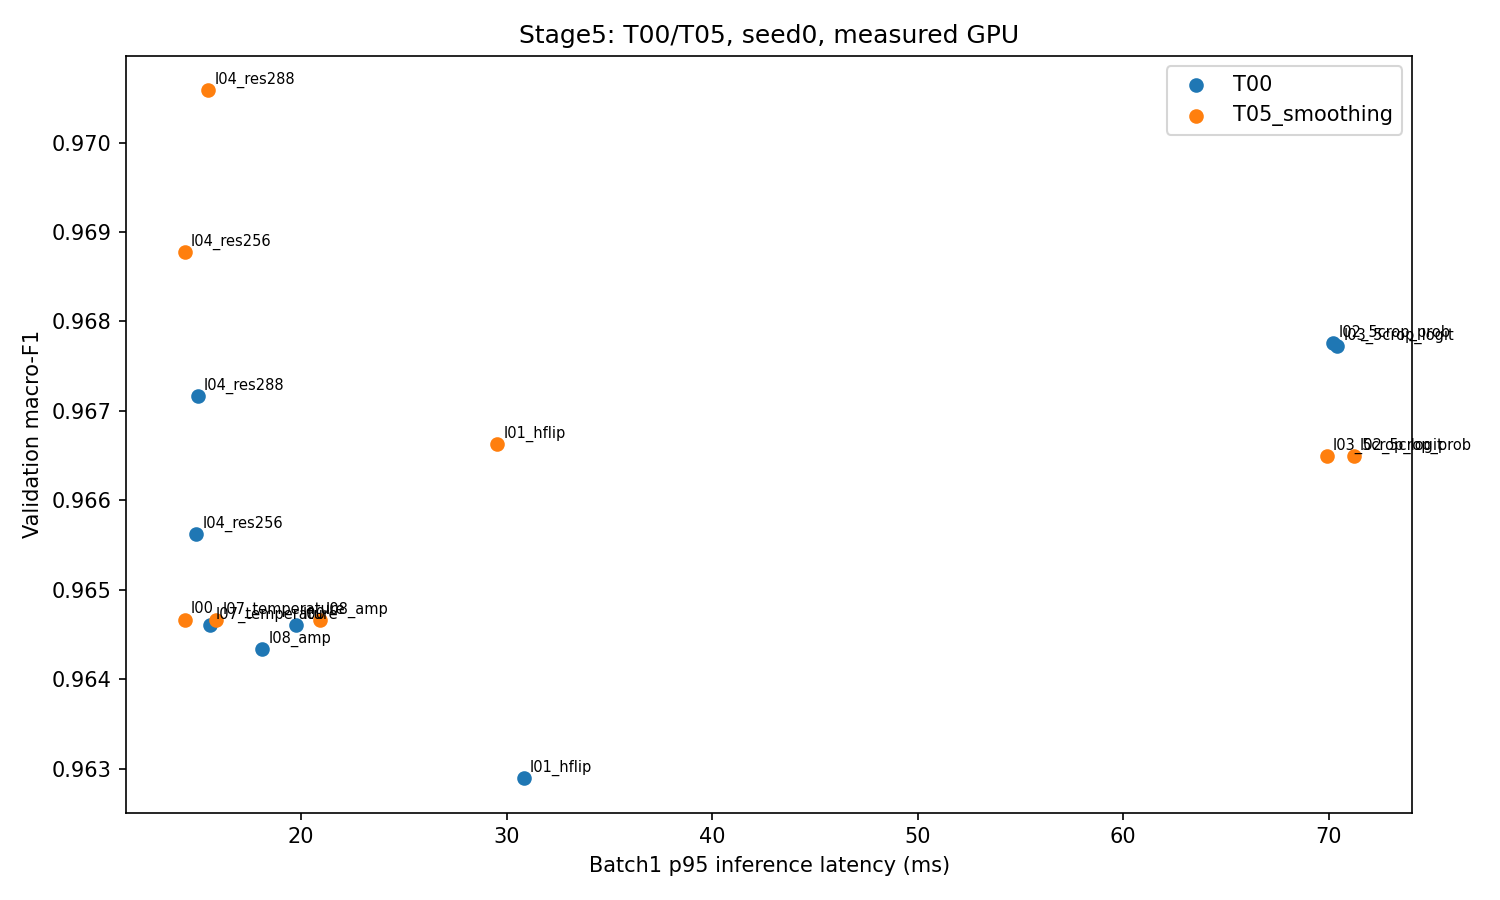

{
  "status": "complete",
  "completed": 16,
  "planned": 16,
  "test_evaluated": false,
  "final_recipe_frozen": false,
  "calibration_metrics": "Temperature fitted and evaluated on full val; apparent fit, not independent calibration evaluation.",
  "val_leader": {
    "training_exp": "T05_smoothing",
    "method": "I04_res288"
  }
}
Gửi lại /kaggle/working/stage5_results.zip; giữ output chặng4 có checkpoint.
Chưa chốt final; sẽ đọc kết quả val, calibration và p95 trước chặng6 nhiều seed.


In [20]:
import pandas as pd
from IPython.display import display,Image
display(pd.read_csv(OUT/'inference.csv'))
if (OUT/'inference_tradeoff.png').exists():display(Image(filename=str(OUT/'inference_tradeoff.png')))
print(json.dumps(report,indent=2))
print('Gửi lại /kaggle/working/stage5_results.zip; giữ output chặng4 có checkpoint.')
print('Chưa chốt final; sẽ đọc kết quả val, calibration và p95 trước chặng6 nhiều seed.')
